# Análise de Contratações & Propostas

Análise exploratória de dados do dataset `employment-with-offer-synthetic` (dev + staging).

**Seções**

| # | Seção |
|---|---|
| 1 | Configuração & Carregamento dos Dados |
| 2 | Visão Geral do Dataset — shape, tipos, nulos, valores únicos |
| 3 | Cargos — distribuição, senioridade |
| 4 | Categorias — departamento, indústria, tipo de contratação |
| 5 | Status da Proposta & Onboarding |
| 6 | Aceito vs. Não Aceito — resultado da proposta por cargo / categoria |
| 7 | Engenharia de Features — colunas normalizadas & derivadas |
| 8 | Ranking de Atributos por Impacto no WIN / LOSS (lista curada + varredura de todas as 125 colunas) & Análise Descritiva |

## 1. Configuração & Carregamento dos Dados

In [326]:
pip install numpy pandas matplotlib seaborn scipy

You should consider upgrading via the '/Users/filipesilva/Documents/datascience/.venv/bin/python -m pip install --upgrade pip' command.
Note: you may need to restart the kernel to use updated packages.


In [327]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from collections import Counter
import re

# ── estilo visual ──────────────────────────────────────────────────────────────
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams.update({'figure.dpi': 120, 'axes.titlepad': 10})
ACCENT = '#4C72B0'
PALETTE_STATUS = {
    'working':     '#2ca02c',
    'resigned':    '#ff7f0e',
    'transferred': '#1f77b4',
    'lost':        '#d62728',
    'other':       '#9467bd',
}

print('Libraries ready.')

Libraries ready.


In [328]:
# ── Google Colab: montar o Drive se estiver rodando lá ─────────────────────
import sys
IN_COLAB = 'google.colab' in sys.modules

if IN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')
    # ↓ ajuste para o local onde você colocou o arquivo no Drive
    FILE_PATH = '/content/drive/MyDrive/datascience/files/employment-with-offer-synthetic.csv'
else:
    # local / qualquer outro kernel
    FILE_PATH = './data/employment-with-offer-synthetic.csv'

print(f'File path: {FILE_PATH}')

File path: ./data/employment-with-offer-synthetic.csv


In [329]:
df_raw = pd.read_csv(
    FILE_PATH,
    low_memory=False,
    on_bad_lines='warn',   # pula/avisa sobre linhas malformadas de campos multi-linha
)

# trabalha em uma cópia para sempre podermos comparar com o dado bruto
df = df_raw.copy()
print(f'Loaded  →  {df.shape[0]:,} rows  ×  {df.shape[1]} columns')

Loaded  →  73,852 rows  ×  125 columns


---
## 2. Visão Geral do Dataset

In [330]:
df.head(3)

,numberId,id,employeeUserId,companyId,country,updatedAt,updatedBy,createdAt,createdBy,employingEntityId,...,offer_isOfferingSignOnBonus,offer_signOnBonusAmount,offer_noticePeriodTerm,offer_noticePeriodLength,offer_initialHourlyRate,offer_initialAnnualSalaryInContractCurrency,offer_retirementMatchType,offer_retirementMatchPercentage,offer_retirementMatchAmount,offer_variableCompensationTypes
0,25296,emp_6dEn01z5kG3bWwBuMEfkRP,user_40Y33sOxlPtpVRMReHEek5,cmp_vm1e1arp1cpnq1c1cqrnt1,NL,2026-04-28 14:06:35.000,54151,2024-09-17 19:28:14.000,54151,cmp_uont1bqvon1eovq1euquqo,...,NaN,NaN,days,30.0,NaN,105000.0,NaN,NaN,NaN,NaN
1,8590,emp_1DX67yg772qMFWVOiFn9Dl,user_1en1ev1a1e1e1e1c1e1bnq,cmp_1cp1eon1c1en1b1Z1bpqp1,SG,2026-04-28 14:06:35.000,54151,2021-10-07 15:52:15.000,54151,cmp_1apqmsq1dvq1btnqmqqu1Z,...,NaN,NaN,weeks,1.0,NaN,408.0,NaN,NaN,NaN,NaN
2,19420,emp_643doZHZwdd33KLJ0S5aCr,user_1en1ev1a1e1e1e1c1e1bnq,cmp_1cp1eon1c1en1b1Z1bpqp1,SG,2026-04-28 14:06:35.000,54151,2023-03-29 19:08:53.000,54151,cmp_uont1bqvon1eovq1euquqo,...,NaN,NaN,weeks,1.0,NaN,408.0,NaN,NaN,NaN,NaN


In [331]:
df.info(verbose=False, show_counts=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 73852 entries, 0 to 73851
Columns: 125 entries, numberId to offer_variableCompensationTypes
dtypes: bool(3), float64(34), int64(3), object(85)
memory usage: 69.0+ MB


In [332]:
# ── Perfil de nulos / completude ───────────────────────────────────────────
null_pct = (df.isnull().sum() / len(df) * 100).sort_values(ascending=False)
null_df  = pd.DataFrame({
    'null_count': df.isnull().sum(),
    'null_pct':   null_pct.round(1),
    'unique':     df.nunique(),
    'dtype':      df.dtypes,
}).sort_values('null_pct', ascending=False)

print('=== Top 30 columns by % missing ===')
null_df.head(30)

=== Top 30 columns by % missing ===


,null_count,null_pct,unique,dtype
offer_employeeCurrentNoticeDays,73852,100.0,0,float64
offer_annualLeaveCarryoverDays,73852,100.0,0,float64
offer_additionalAnnualLeaveDays,73852,100.0,0,float64
offer_retirementMatchAmount,73852,100.0,0,float64
hourlyRate,73852,100.0,0,float64
offer_isCarAllowanceOffered,73777,99.9,2,object
offer_isTransportationAllowanceOffered,73775,99.9,1,object
offer_schoolAllowanceAmount,73794,99.9,19,float64
offer_flightAllowanceAmount,73784,99.9,9,float64
offer_initialHourlyRate,73801,99.9,26,float64


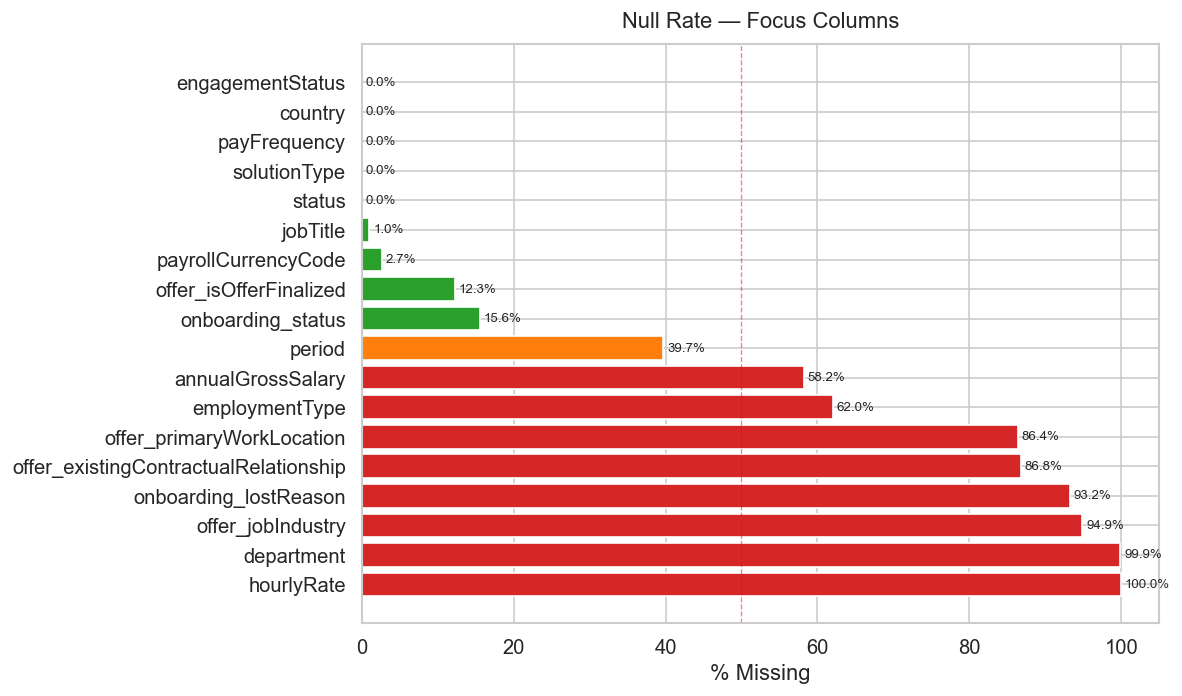

,null_count,null_pct,unique,dtype
hourlyRate,73852,100.0,0,float64
department,73805,99.9,38,object
offer_jobIndustry,70119,94.9,639,object
onboarding_lostReason,68826,93.2,25,object
offer_existingContractualRelationship,64123,86.8,3,object
offer_primaryWorkLocation,63839,86.4,4,object
employmentType,45822,62.0,2,object
annualGrossSalary,43002,58.2,7791,float64
period,29313,39.7,12,object
onboarding_status,11550,15.6,5,object


In [333]:
# ── Colunas de foco para a análise ────────────────────────────────────────
FOCUS_COLS = [
    'status', 'engagementStatus', 'employmentType', 'solutionType',
    'country', 'department', 'jobTitle', 'payFrequency', 'period',
    'annualGrossSalary', 'hourlyRate', 'payrollCurrencyCode',
    'onboarding_status', 'onboarding_lostReason',
    'offer_jobIndustry', 'offer_existingContractualRelationship',
    'offer_primaryWorkLocation', 'offer_isOfferFinalized',
]
focus_null = null_df.loc[null_df.index.isin(FOCUS_COLS)]

fig, ax = plt.subplots(figsize=(10, 6))
colors   = ['#d62728' if v > 50 else '#ff7f0e' if v > 20 else '#2ca02c'
             for v in focus_null['null_pct']]
bars = ax.barh(focus_null.index, focus_null['null_pct'], color=colors)
ax.set_xlabel('% Missing')
ax.set_title('Null Rate — Focus Columns')
ax.axvline(50, color='red', ls='--', lw=0.8, alpha=0.5)
for bar, val in zip(bars, focus_null['null_pct']):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}%', va='center', fontsize=8)
plt.tight_layout()
plt.show()

focus_null[['null_count', 'null_pct', 'unique', 'dtype']]

In [334]:
# ── Contagem rápida de valores únicos para categóricas de baixa cardinalidade ────
LOW_CARD = ['status', 'engagementStatus', 'employmentType', 'solutionType',
            'payFrequency', 'period', 'onboarding_status',
            'offer_primaryWorkLocation', 'offer_existingContractualRelationship']

for col in LOW_CARD:
    if col in df.columns:
        vc = df[col].value_counts(dropna=False)
        print(f"\n{col} ({df[col].nunique()} unique):")
        print(vc.to_string())


status (10 unique):
status
hiring_process     24086
working            18487
terminated         12512
resigned            8871
lost                6407
transferred         2018
completed           1084
duplicate            229
ready_to_start       151
temporary_leave        7

engagementStatus (10 unique):
engagementStatus
hiring_process     24086
working            18487
terminated         12512
resigned            8871
lost                6407
transferred         2018
completed           1084
duplicate            229
ready_to_start       151
temporary_leave        7

employmentType (2 unique):
employmentType
NaN          45822
full_time    27454
part_time      576

solutionType (3 unique):
solutionType
Supported Employee       72506
Multi-Country Payroll     1150
Contractor Payments        196

payFrequency (5 unique):
payFrequency
monthly                 36269
no_payroll_frequency    31027
semi_monthly             6237
bi_weekly                 262
weekly                     57

pe

---
## 3. Cargos

Total rows with a jobTitle: 73,109  (99.0%)
Distinct job titles: 16,776


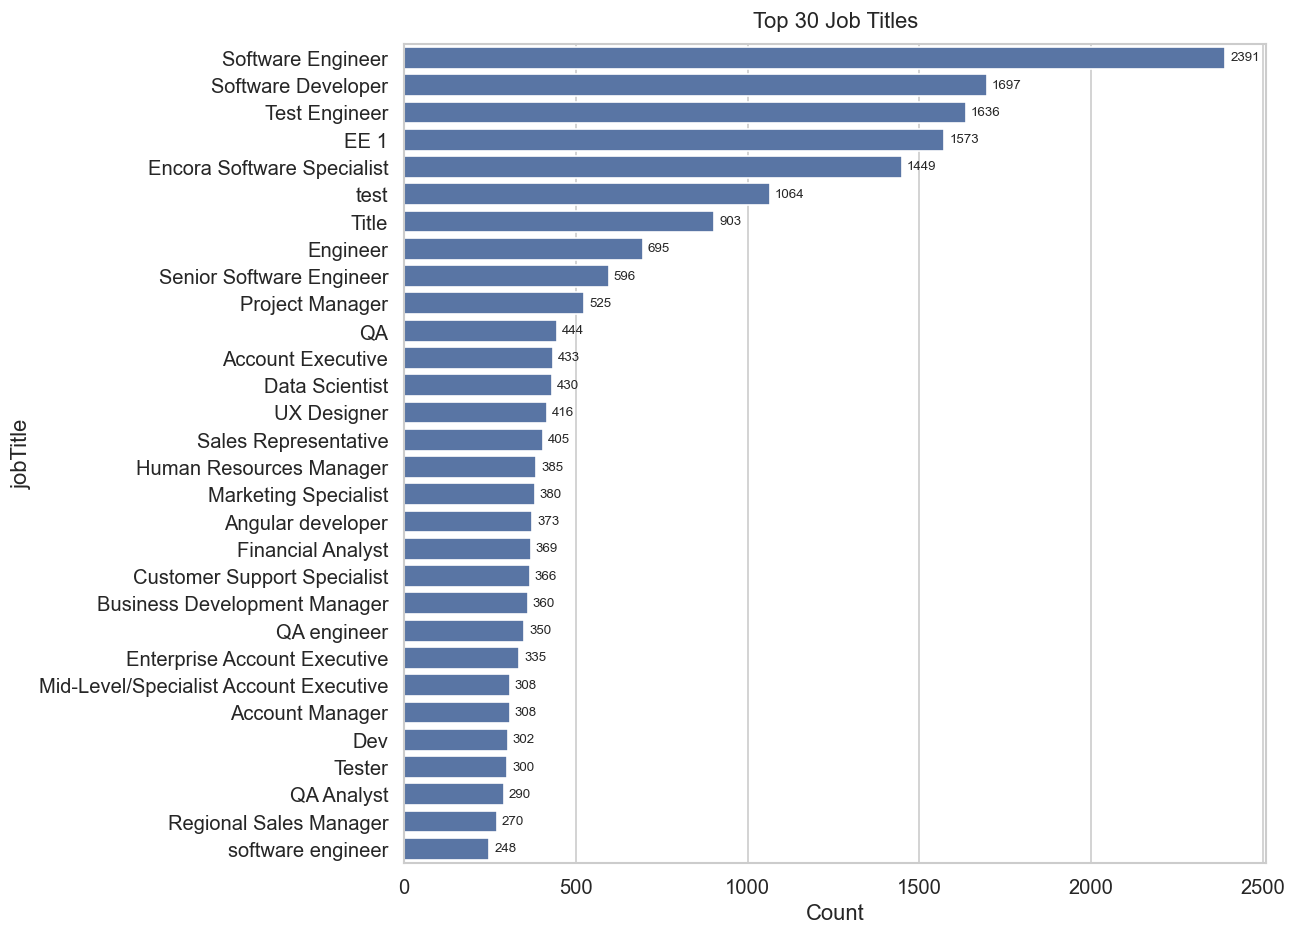

In [335]:
jt = df['jobTitle'].dropna().str.strip()
print(f'Total rows with a jobTitle: {len(jt):,}  ({len(jt)/len(df)*100:.1f}%)')
print(f'Distinct job titles: {jt.nunique():,}')

top_jt = jt.value_counts().head(30)

fig, ax = plt.subplots(figsize=(11, 8))
sns.barplot(x=top_jt.values, y=top_jt.index, ax=ax, color=ACCENT)
ax.set_xlabel('Count')
ax.set_title('Top 30 Job Titles')
ax.bar_label(ax.containers[0], padding=3, fontsize=8)
plt.tight_layout()
plt.show()

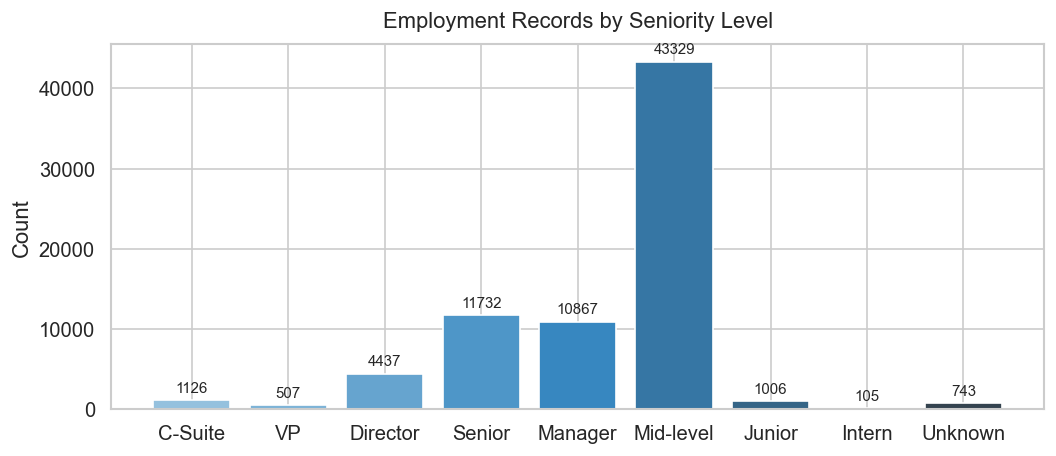

seniority_level
C-Suite       1126
VP             507
Director      4437
Senior       11732
Manager      10867
Mid-level    43329
Junior        1006
Intern         105
Unknown        743


In [336]:
# ── Nível de senioridade extraído do cargo ─────────────────────────────
SENIORITY_MAP = [
    (r'\bC[ETO]O\b|\bChief\b|\bPresident\b|\bFounder\b',              'C-Suite'),
    (r'\bVP\b|\bVice President\b',                                      'VP'),
    (r'\bDirector\b',                                                   'Director'),
    (r'\bSenior\b|\bSr\.?\b|\bLead\b|\bPrincipal\b|\bStaff\b',       'Senior'),
    (r'\bManager\b|\bHead\b|\bSupervisor\b',                           'Manager'),
    (r'\bJunior\b|\bJr\.?\b|\bAssociate\b|\bEntry\b|\bTrainee\b',    'Junior'),
    (r'\bIntern\b',                                                    'Intern'),
]

def extract_seniority(title):
    if pd.isna(title):
        return 'Unknown'
    for pattern, label in SENIORITY_MAP:
        if re.search(pattern, str(title), re.IGNORECASE):
            return label
    return 'Mid-level'

df['seniority_level'] = df['jobTitle'].apply(extract_seniority)

seniority_order = ['C-Suite', 'VP', 'Director', 'Senior', 'Manager', 'Mid-level', 'Junior', 'Intern', 'Unknown']
sen_counts = df['seniority_level'].value_counts().reindex(seniority_order).dropna()

fig, ax = plt.subplots(figsize=(9, 4))
palette  = sns.color_palette('Blues_d', len(sen_counts))
bars     = ax.bar(sen_counts.index, sen_counts.values, color=palette)
ax.set_title('Employment Records by Seniority Level')
ax.set_ylabel('Count')
ax.bar_label(bars, padding=3, fontsize=9)
plt.tight_layout()
plt.show()

print(sen_counts.to_string())

---
## 4. Categorias — Departamento, Indústria, Tipo de Contratação

Distinct departments: 38


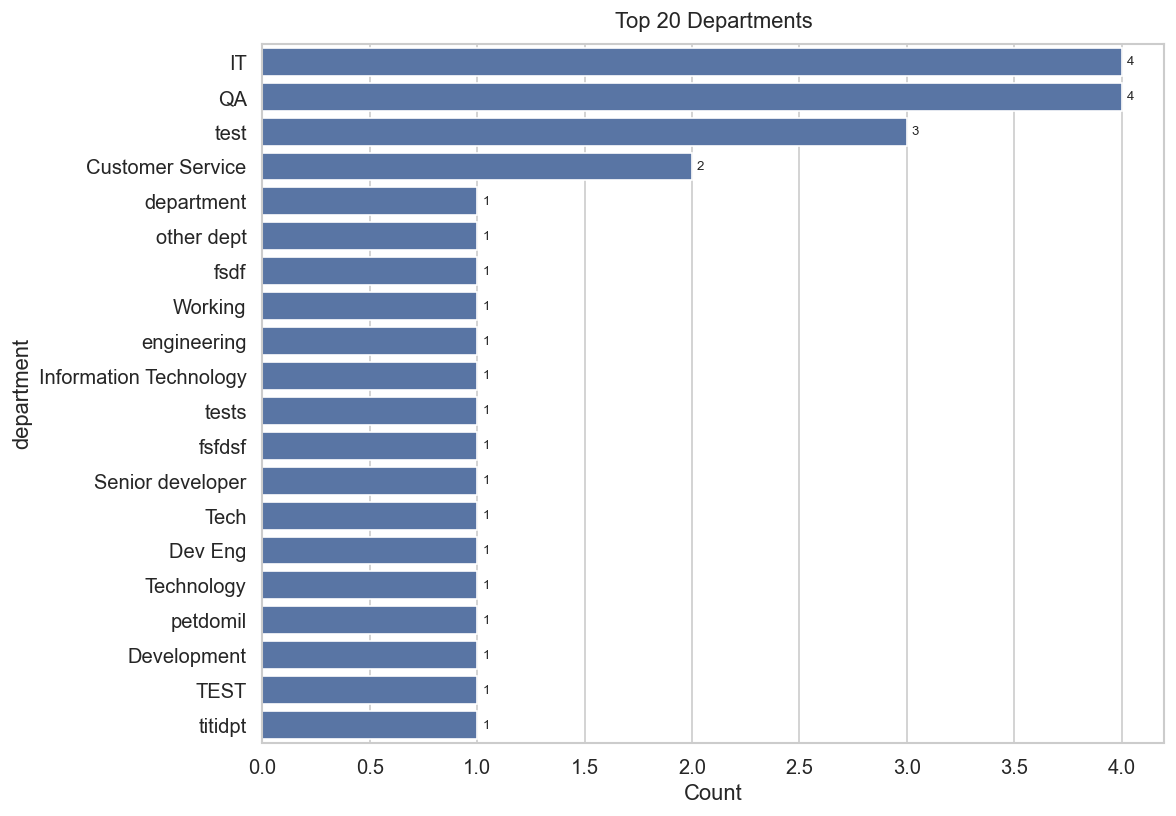

In [337]:
dept = df['department'].dropna().str.strip()
print(f'Distinct departments: {dept.nunique()}')
top_dept = dept.value_counts().head(20)

fig, ax = plt.subplots(figsize=(10, 7))
sns.barplot(x=top_dept.values, y=top_dept.index, ax=ax, color=ACCENT)
ax.set_title('Top 20 Departments')
ax.set_xlabel('Count')
ax.bar_label(ax.containers[0], padding=3, fontsize=8)
plt.tight_layout()
plt.show()

> **Nota de qualidade dos dados — `department`**
>
> `department` está 99,9% vazia (apenas ~26 de 35.366 linhas preenchidas). Isso é esparso
> demais para representar a população real — provavelmente é dado de teste/seed residual,
> e não um sinal genuíno. **Excluindo `department` das análises seguintes neste notebook.**

Distinct industries: 639


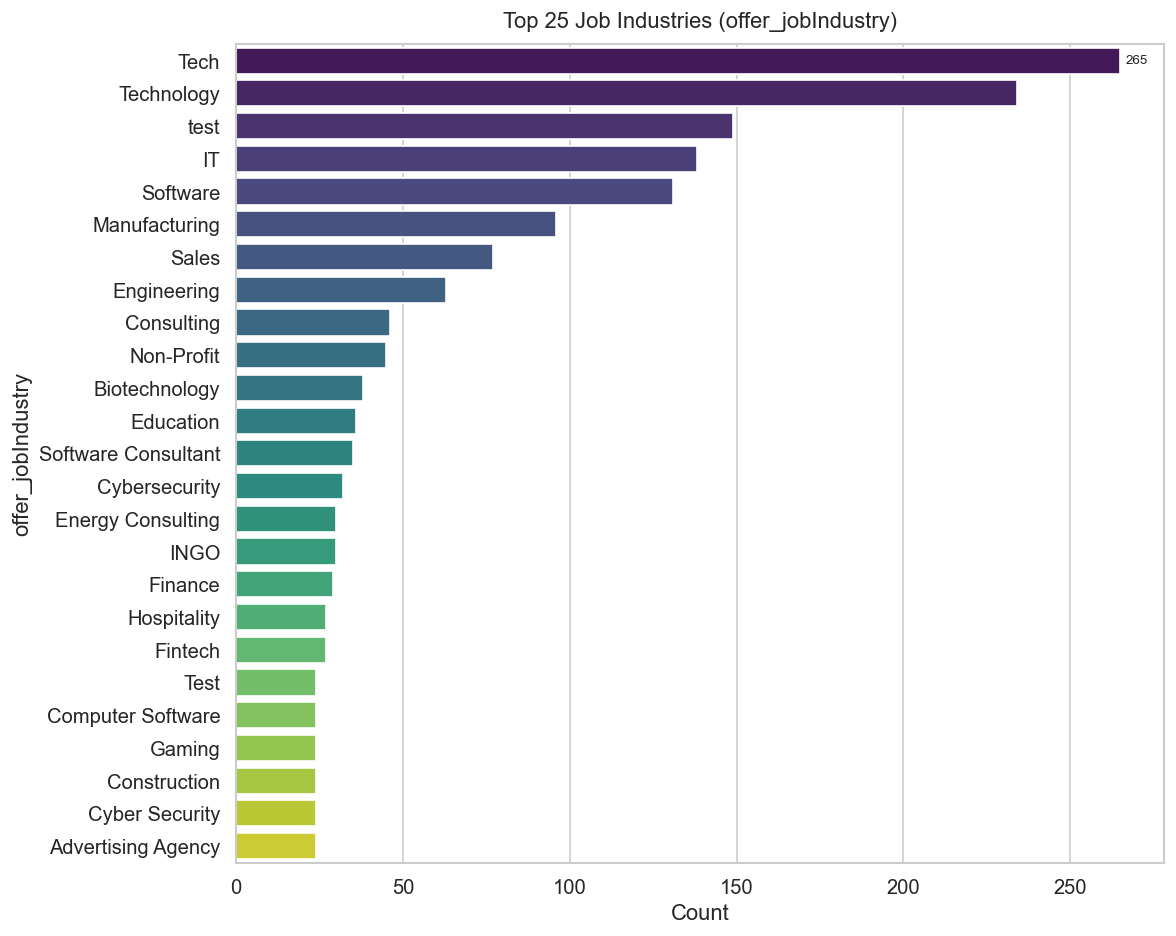

In [338]:
ind = df['offer_jobIndustry'].dropna().str.strip()
print(f'Distinct industries: {ind.nunique()}')
top_ind = ind.value_counts().head(25)

fig, ax = plt.subplots(figsize=(10, 8))
sns.barplot(x=top_ind.values, y=top_ind.index, ax=ax,
            palette=sns.color_palette('viridis', len(top_ind)))
ax.set_title('Top 25 Job Industries (offer_jobIndustry)')
ax.set_xlabel('Count')
ax.bar_label(ax.containers[0], padding=3, fontsize=8)
plt.tight_layout()
plt.show()

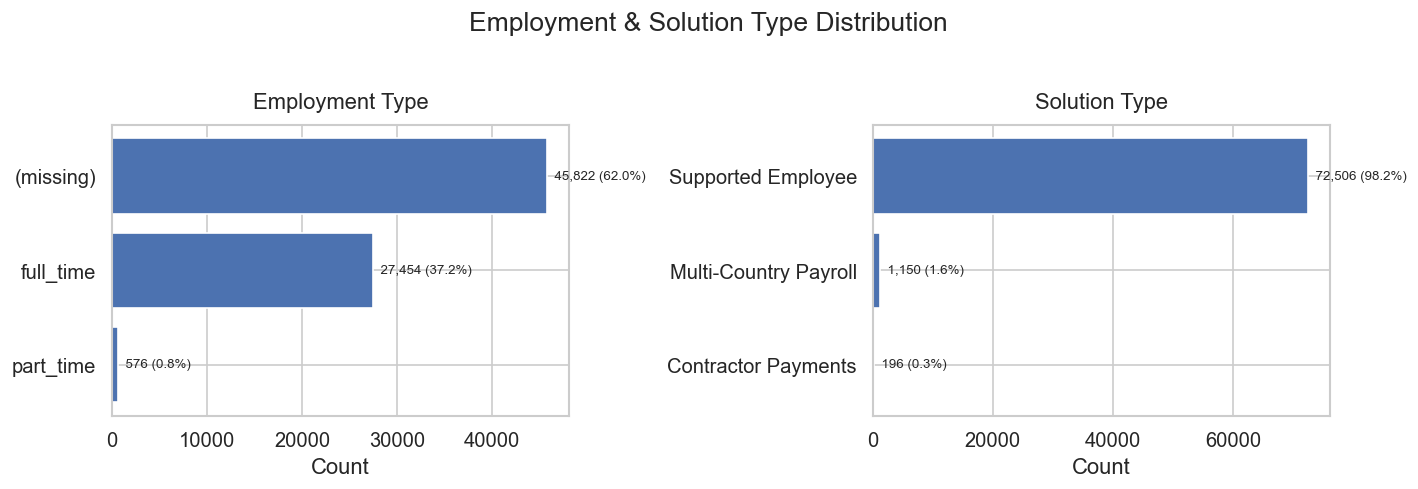

In [339]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, col, title in [
    (axes[0], 'employmentType', 'Employment Type'),
    (axes[1], 'solutionType',   'Solution Type'),
]:
    vc  = df[col].fillna('(missing)').value_counts()
    pct = vc / vc.sum() * 100
    bars = ax.barh(vc.index[::-1], vc.values[::-1], color=ACCENT)
    ax.set_title(title)
    ax.set_xlabel('Count')
    for bar, cnt, p in zip(bars, vc.values[::-1], pct.values[::-1]):
        ax.text(bar.get_width(), bar.get_y() + bar.get_height() / 2,
                f'  {cnt:,} ({p:.1f}%)', va='center', fontsize=8)

plt.suptitle('Employment & Solution Type Distribution', y=1.02)
plt.tight_layout()
plt.show()

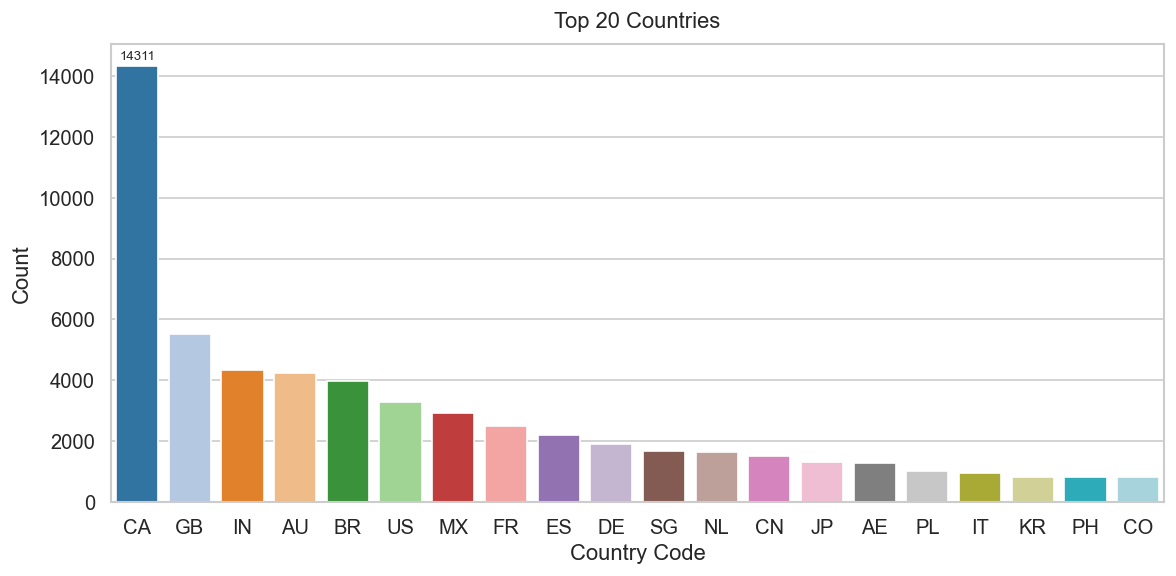

In [340]:
top_countries = df['country'].value_counts().head(20)

fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(x=top_countries.index, y=top_countries.values, ax=ax,
            palette='tab20')
ax.set_title('Top 20 Countries')
ax.set_ylabel('Count')
ax.set_xlabel('Country Code')
ax.bar_label(ax.containers[0], padding=2, fontsize=8)
plt.tight_layout()
plt.show()

---
## 5. Status da Proposta & Onboarding

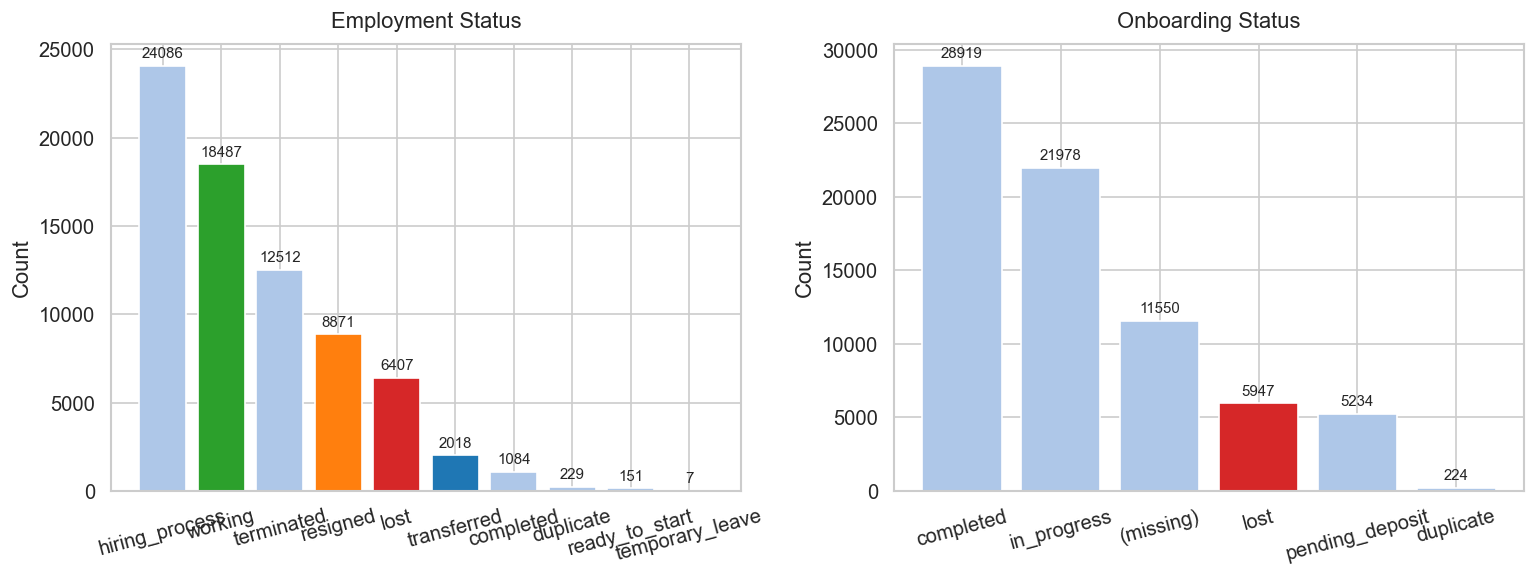

In [341]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, col, title in [
    (axes[0], 'status',           'Employment Status'),
    (axes[1], 'onboarding_status','Onboarding Status'),
]:
    vc     = df[col].fillna('(missing)').value_counts()
    colors = [PALETTE_STATUS.get(k, '#aec7e8') for k in vc.index]
    bars   = ax.bar(vc.index, vc.values, color=colors)
    ax.set_title(title)
    ax.set_ylabel('Count')
    ax.bar_label(bars, padding=3, fontsize=9)
    ax.tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()

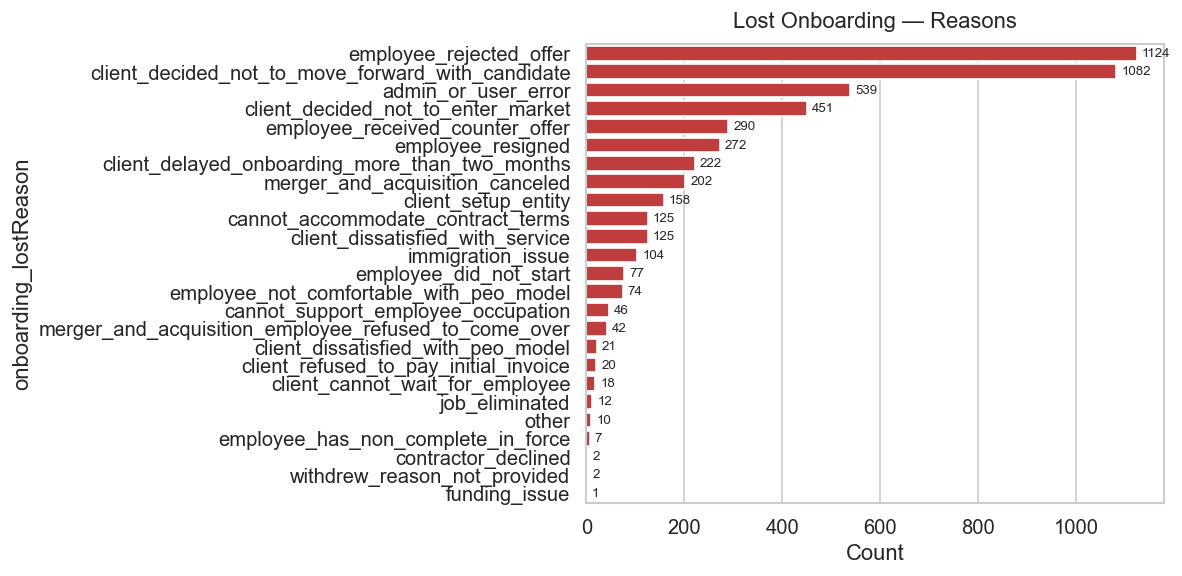

onboarding_lostReason
employee_rejected_offer                                 1124
client_decided_not_to_move_forward_with_candidate       1082
admin_or_user_error                                      539
client_decided_not_to_enter_market                       451
employee_received_counter_offer                          290
employee_resigned                                        272
client_delayed_onboarding_more_than_two_months           222
merger_and_acquisition_canceled                          202
client_setup_entity                                      158
cannot_accommodate_contract_terms                        125
client_dissatisfied_with_service                         125
immigration_issue                                        104
employee_did_not_start                                    77
employee_not_comfortable_with_peo_model                   74
cannot_support_employee_occupation                        46
merger_and_acquisition_employee_refused_to_come_over      42
cl

In [342]:
lost_reasons = df['onboarding_lostReason'].dropna().value_counts()

fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(x=lost_reasons.values, y=lost_reasons.index, ax=ax,
            color='#d62728')
ax.set_title('Lost Onboarding — Reasons')
ax.set_xlabel('Count')
ax.bar_label(ax.containers[0], padding=3, fontsize=8)
plt.tight_layout()
plt.show()

lost_reasons

---
## 6. Aceito vs. Não Aceito — Resultado da Proposta

**Classificação**
- `accepted` → `status` em {`working`, `transferred`, `resigned`}  
  (a proposta foi aceita e a pessoa iniciou; eventos posteriores como demissão não mudam o resultado da proposta)
- `lost` → `status == 'lost'`  
- `other/unknown` → todo o resto

               count   pct
offer_outcome             
other          38069  51.5
accepted       29376  39.8
lost            6407   8.7


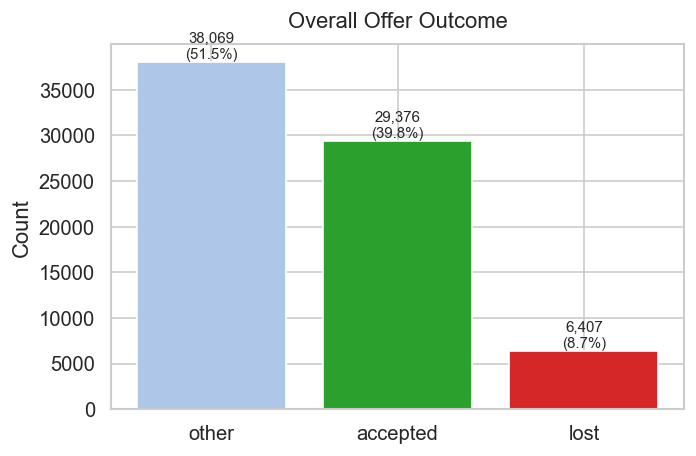

In [343]:
ACCEPTED_STATUSES = {'working', 'transferred', 'resigned'}

def offer_outcome(row):
    s = str(row.get('status', '') or '').lower().strip()
    if s in ACCEPTED_STATUSES:
        return 'accepted'
    elif s == 'lost':
        return 'lost'
    else:
        return 'other'

df['offer_outcome'] = df.apply(offer_outcome, axis=1)

outcome_colors = {'accepted': '#2ca02c', 'lost': '#d62728', 'other': '#aec7e8'}
oc  = df['offer_outcome'].value_counts()
pct = (oc / oc.sum() * 100).round(1)
print(pd.DataFrame({'count': oc, 'pct': pct}).to_string())

fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(oc.index, oc.values, color=[outcome_colors[k] for k in oc.index])
ax.set_title('Overall Offer Outcome')
ax.set_ylabel('Count')
for bar, cnt, p in zip(bars, oc.values, pct.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height(),
            f'{cnt:,}\n({p:.1f}%)', ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.show()

### 6b. Resultado simplificado WIN / LOSS

Uma versão mais simples, em dois grupos, de `status`, que classifica todo registro como um
ganho ou perda claro (sem grupo `other`/`unknown` — todo valor de status é atribuído):

- **WIN** → `hiring_process`, `working`, `transferred`, `completed`, `ready_to_start`, `temporary_leave`
- **LOSS** → `terminated`, `resigned`, `lost`, `duplicate`

          count   pct
win_loss             
WIN       45833  62.1
LOSS      28019  37.9


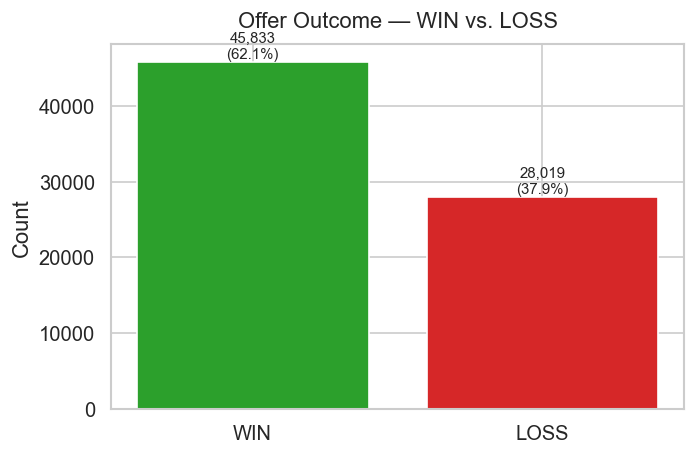

In [344]:
WIN_STATUSES = {
    'hiring_process', 'working', 'transferred',
    'completed', 'ready_to_start', 'temporary_leave',
}
LOSS_STATUSES = {'terminated', 'resigned', 'lost', 'duplicate'}

def win_loss(status):
    s = str(status).lower().strip()
    if s in WIN_STATUSES:
        return 'WIN'
    if s in LOSS_STATUSES:
        return 'LOSS'
    return 'UNKNOWN'  # sinaliza qualquer status não coberto acima, ex.: novos valores futuros

df['win_loss'] = df['status'].apply(win_loss)

wl_colors = {'WIN': '#2ca02c', 'LOSS': '#d62728', 'UNKNOWN': '#aec7e8'}
wl_counts = df['win_loss'].value_counts()
wl_pct    = (wl_counts / wl_counts.sum() * 100).round(1)

print(pd.DataFrame({'count': wl_counts, 'pct': wl_pct}).to_string())

fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(wl_counts.index, wl_counts.values,
               color=[wl_colors[k] for k in wl_counts.index])
ax.set_title('Offer Outcome — WIN vs. LOSS')
ax.set_ylabel('Count')
for bar, cnt, pct in zip(bars, wl_counts.values, wl_pct.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height(),
            f'{cnt:,}\n({pct:.1f}%)', ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.show()

### 6c. WIN / LOSS por Cargo

Contagens empilhadas de `win_loss` para os 20 cargos mais frequentes (linhas com `UNKNOWN`
excluídas), coloridas com o mesmo esquema verde/vermelho do gráfico geral de WIN/LOSS acima.

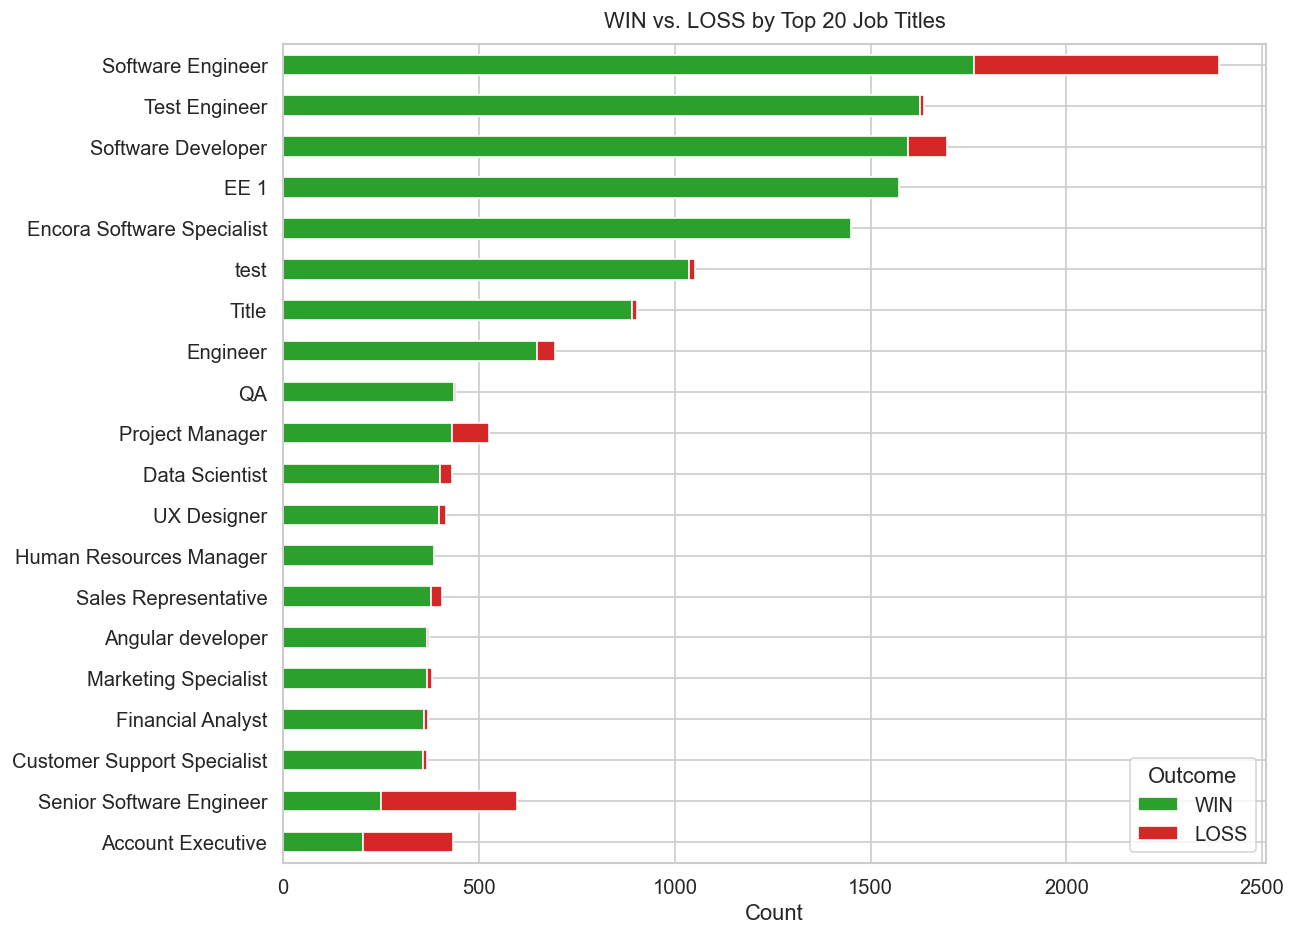

In [345]:
# ── WIN/LOSS pelos cargos mais frequentes ────────────────────────────────────
TOP_N = 20
top_titles_list = df['jobTitle'].dropna().value_counts().head(TOP_N).index.tolist()

jt_wl = (
    df[df['jobTitle'].isin(top_titles_list) & df['win_loss'].isin(['WIN', 'LOSS'])]
    .groupby(['jobTitle', 'win_loss'])
    .size()
    .unstack(fill_value=0)
)
jt_wl = jt_wl[[c for c in ['WIN', 'LOSS'] if c in jt_wl.columns]]
jt_wl = jt_wl.sort_values('WIN', ascending=True)

fig, ax = plt.subplots(figsize=(11, 8))
jt_wl.plot(kind='barh', stacked=True, ax=ax,
           color=[wl_colors[c] for c in jt_wl.columns])
ax.set_title(f'WIN vs. LOSS by Top {TOP_N} Job Titles')
ax.set_xlabel('Count')
ax.set_ylabel('')
ax.legend(title='Outcome', loc='lower right')
plt.tight_layout()
plt.show()

### 6d. Taxa de Vitória por Nível de Senioridade

`win_rate = WIN / (WIN + LOSS) × 100` por grupo de senioridade. Barras acima da linha de
referência de 50% (tracejada) são coloridas em verde (WIN); abaixo, em vermelho (LOSS).

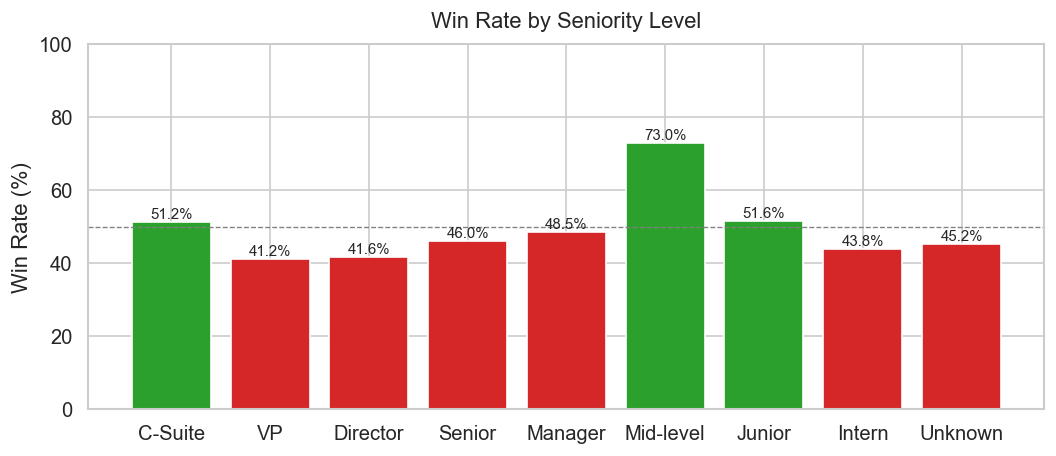

win_loss,LOSS,WIN,win_rate
seniority_level,,,
C-Suite,550,576,51.2
VP,298,209,41.2
Director,2589,1848,41.6
Senior,6334,5398,46.0
Manager,5592,5275,48.5
Mid-level,11703,31626,73.0
Junior,487,519,51.6
Intern,59,46,43.8
Unknown,407,336,45.2


In [346]:
# ── Taxa de vitória por senioridade ───────────────────────────────────────────
sen_wl = (
    df[df['win_loss'].isin(['WIN', 'LOSS'])]
    .groupby(['seniority_level', 'win_loss'])
    .size()
    .unstack(fill_value=0)
)
sen_wl['win_rate'] = (sen_wl.get('WIN', 0) / sen_wl.sum(axis=1) * 100).round(1)
sen_wl = sen_wl.reindex(seniority_order).dropna(how='all')

fig, ax = plt.subplots(figsize=(9, 4))
colors = [wl_colors['WIN'] if v >= 50 else wl_colors['LOSS'] for v in sen_wl['win_rate']]
ax.bar(sen_wl.index, sen_wl['win_rate'], color=colors)
ax.set_title('Win Rate by Seniority Level')
ax.set_ylabel('Win Rate (%)')
ax.set_ylim(0, 100)
ax.axhline(50, color='grey', ls='--', lw=0.8)
for i, (idx, row) in enumerate(sen_wl.iterrows()):
    ax.text(i, row['win_rate'] + 1, f"{row['win_rate']:.1f}%", ha='center', fontsize=9)
plt.tight_layout()
plt.show()

sen_wl

### 6e. Taxa de Vitória por Indústria

Mesma lógica de taxa de vitória, aplicada a `offer_jobIndustry`. Restrita a indústrias com
pelo menos 10 registros, para que a taxa não seja dominada por poucas propostas isoladas.

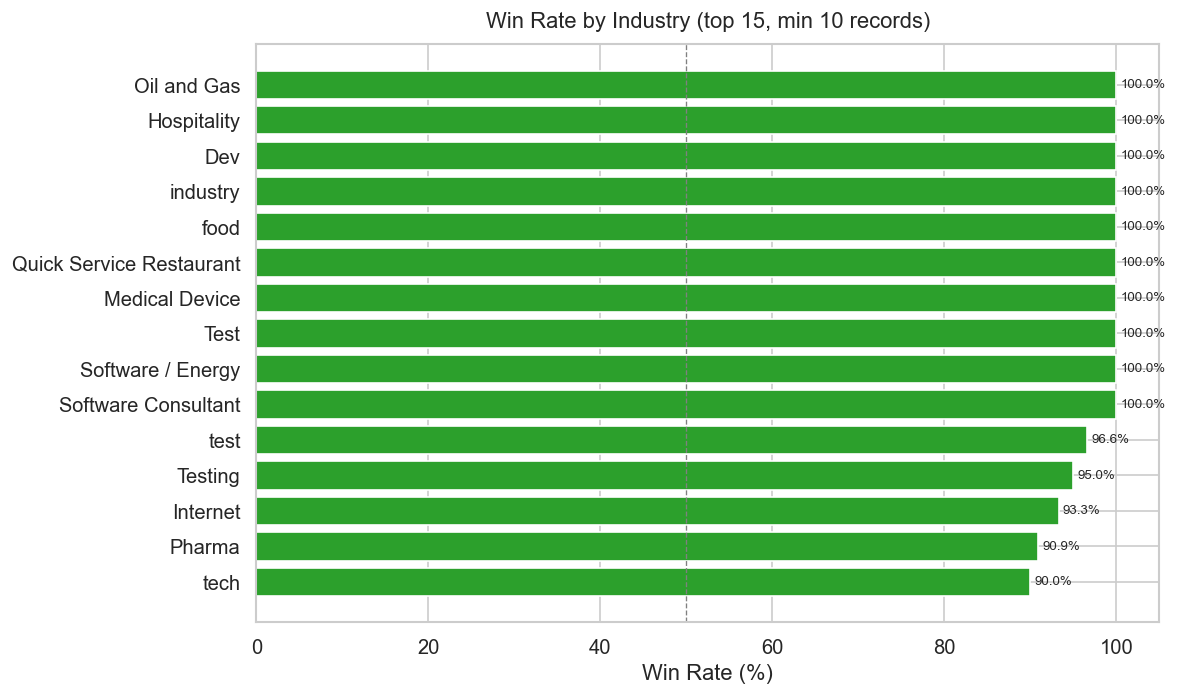

In [347]:
# ── Taxa de vitória por indústria (mín. 10 registros) ─────────────────────────
ind_wl = (
    df[df['win_loss'].isin(['WIN', 'LOSS']) & df['offer_jobIndustry'].notna()]
    .groupby(['offer_jobIndustry', 'win_loss'])
    .size()
    .unstack(fill_value=0)
)
ind_wl['total'] = ind_wl.sum(axis=1)
ind_wl['win_rate'] = (ind_wl.get('WIN', 0) / ind_wl['total'] * 100).round(1)

ind_top = (
    ind_wl[ind_wl['total'] >= 10]
    .sort_values('win_rate', ascending=True)
    .tail(15)
)

fig, ax = plt.subplots(figsize=(10, 6))
colors = [wl_colors['WIN'] if v >= 50 else wl_colors['LOSS'] for v in ind_top['win_rate']]
bars = ax.barh(ind_top.index, ind_top['win_rate'], color=colors)
ax.set_title('Win Rate by Industry (top 15, min 10 records)')
ax.set_xlabel('Win Rate (%)')
ax.set_xlim(0, 105)
ax.axvline(50, color='grey', ls='--', lw=0.8)
for bar, val in zip(bars, ind_top['win_rate']):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height() / 2,
            f'{val:.1f}%', va='center', fontsize=8)
plt.tight_layout()
plt.show()

### 6f. Taxa de Vitória por País

Mesma lógica de taxa de vitória, aplicada aos 20 países com maior volume, ordenados de
forma decrescente pela taxa de vitória.

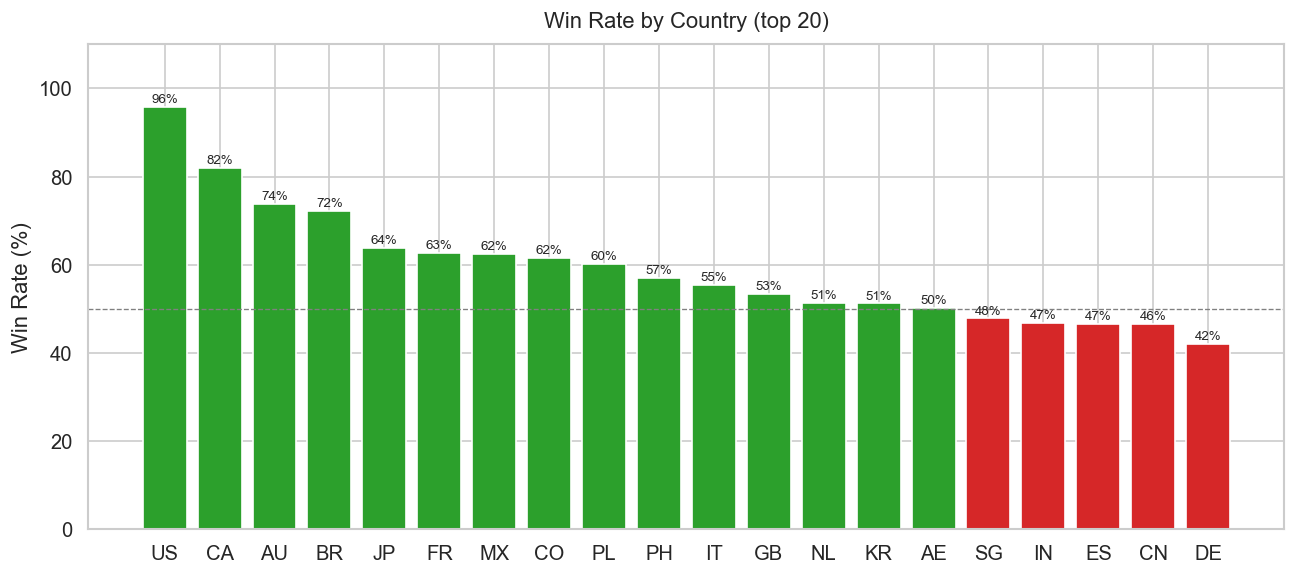

win_loss,WIN,LOSS,total,win_rate
country,,,,
US,3143,138,3281,95.8
CA,11716,2595,14311,81.9
AU,3143,1113,4256,73.8
BR,2880,1116,3996,72.1
JP,836,474,1310,63.8
FR,1575,940,2515,62.6
MX,1826,1100,2926,62.4
CO,504,315,819,61.5
PL,612,404,1016,60.2


In [348]:
# ── Taxa de vitória por país (top 20) ─────────────────────────────────────────
top_country_list = df['country'].value_counts().head(20).index

ctry_wl = (
    df[df['country'].isin(top_country_list) & df['win_loss'].isin(['WIN', 'LOSS'])]
    .groupby(['country', 'win_loss'])
    .size()
    .unstack(fill_value=0)
)
ctry_wl['total'] = ctry_wl.sum(axis=1)
ctry_wl['win_rate'] = (ctry_wl.get('WIN', 0) / ctry_wl['total'] * 100).round(1)
ctry_wl = ctry_wl.sort_values('win_rate', ascending=False)

fig, ax = plt.subplots(figsize=(11, 5))
colors = [wl_colors['WIN'] if v >= 50 else wl_colors['LOSS'] for v in ctry_wl['win_rate']]
ax.bar(ctry_wl.index, ctry_wl['win_rate'], color=colors)
ax.set_title('Win Rate by Country (top 20)')
ax.set_ylabel('Win Rate (%)')
ax.set_ylim(0, 110)
ax.axhline(50, color='grey', ls='--', lw=0.8)
for i, (idx, row) in enumerate(ctry_wl.iterrows()):
    ax.text(i, row['win_rate'] + 1, f"{row['win_rate']:.0f}%", ha='center', fontsize=8)
plt.tight_layout()
plt.show()

ctry_wl[['WIN', 'LOSS', 'total', 'win_rate']]

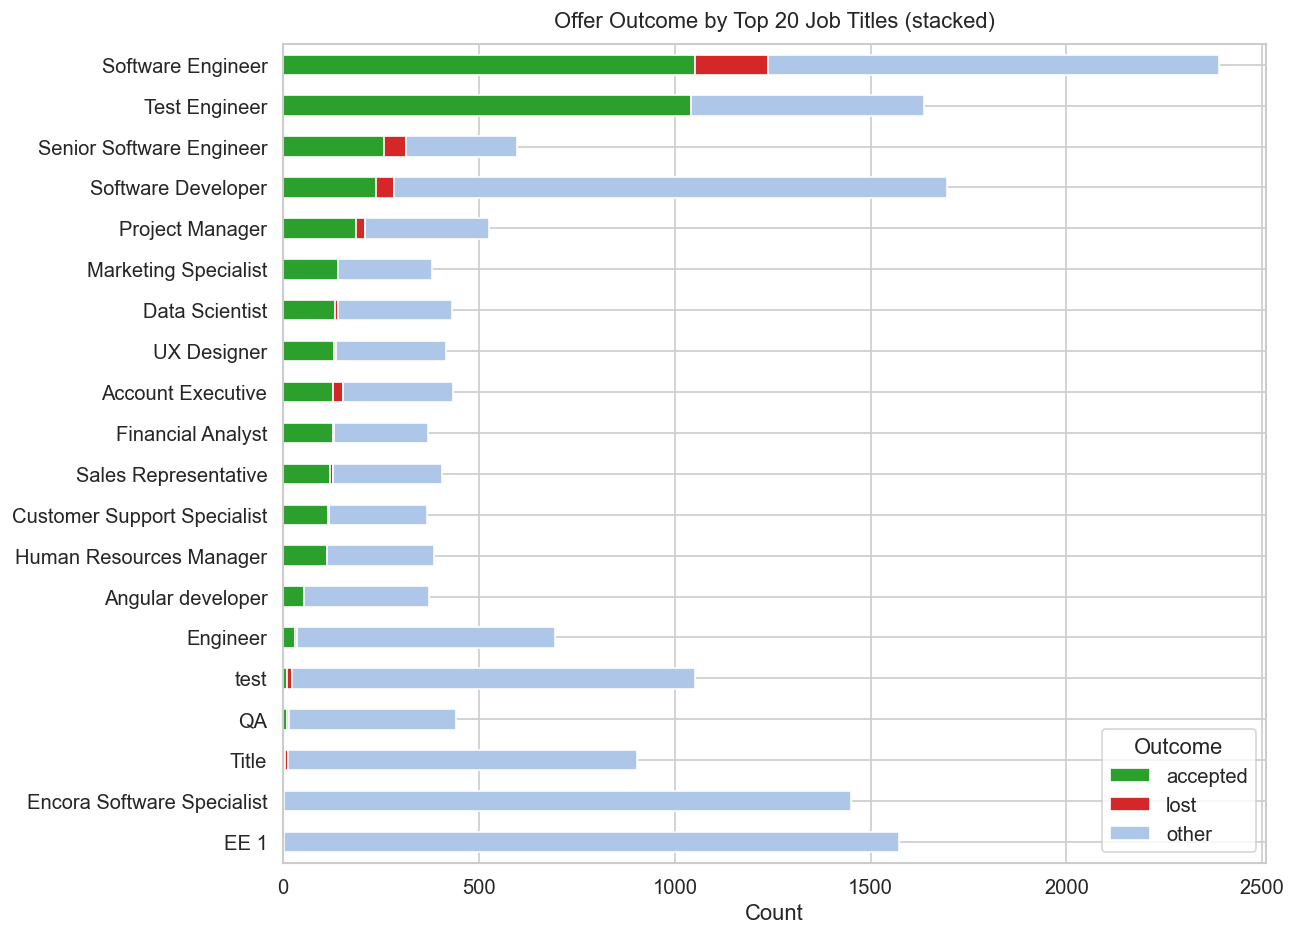

In [349]:
# ── Resultado da proposta pelos cargos mais frequentes ──────────────────────
TOP_N = 20
top_titles_list = df['jobTitle'].dropna().value_counts().head(TOP_N).index.tolist()

jt_outcome = (
    df[df['jobTitle'].isin(top_titles_list)]
    .groupby(['jobTitle', 'offer_outcome'])
    .size()
    .unstack(fill_value=0)
)

# reordena as colunas
col_order = [c for c in ['accepted', 'lost', 'other'] if c in jt_outcome.columns]
jt_outcome = jt_outcome[col_order]
# ordena por 'accepted' decrescente
jt_outcome = jt_outcome.sort_values('accepted' if 'accepted' in jt_outcome else jt_outcome.columns[0], ascending=True)

fig, ax = plt.subplots(figsize=(11, 8))
jt_outcome.plot(kind='barh', stacked=True, ax=ax,
                color=[outcome_colors.get(c, '#aec7e8') for c in jt_outcome.columns])
ax.set_title(f'Offer Outcome by Top {TOP_N} Job Titles (stacked)')
ax.set_xlabel('Count')
ax.set_ylabel('')
ax.legend(title='Outcome', loc='lower right')
plt.tight_layout()
plt.show()

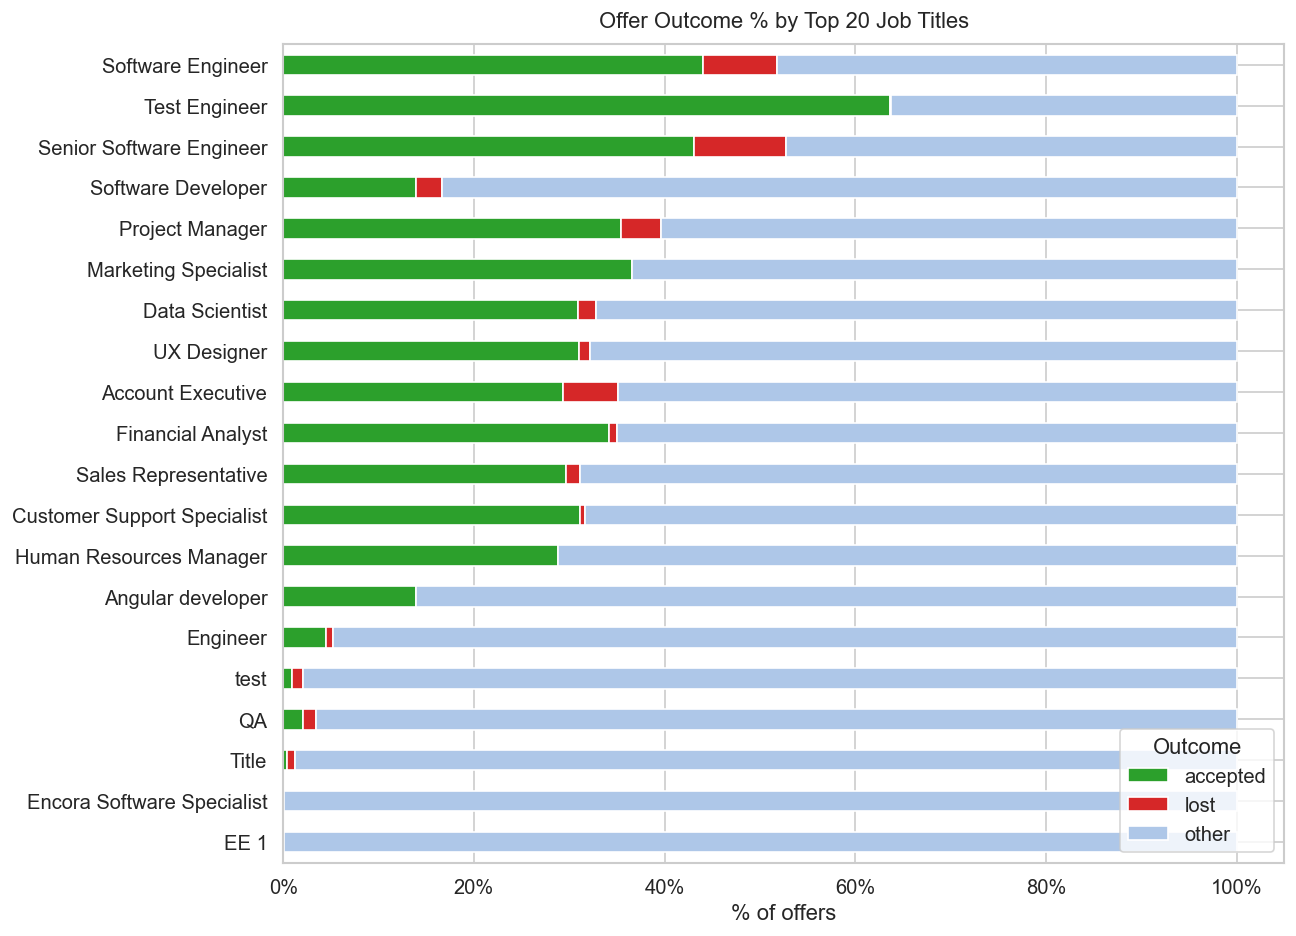

In [350]:
# ── O mesmo, normalizado para 100% ────────────────────────────────────────
jt_pct = jt_outcome.div(jt_outcome.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(11, 8))
jt_pct.plot(kind='barh', stacked=True, ax=ax,
            color=[outcome_colors.get(c, '#aec7e8') for c in jt_pct.columns])
ax.set_title(f'Offer Outcome % by Top {TOP_N} Job Titles')
ax.set_xlabel('% of offers')
ax.set_ylabel('')
ax.xaxis.set_major_formatter(mticker.PercentFormatter())
ax.legend(title='Outcome', loc='lower right')
plt.tight_layout()
plt.show()

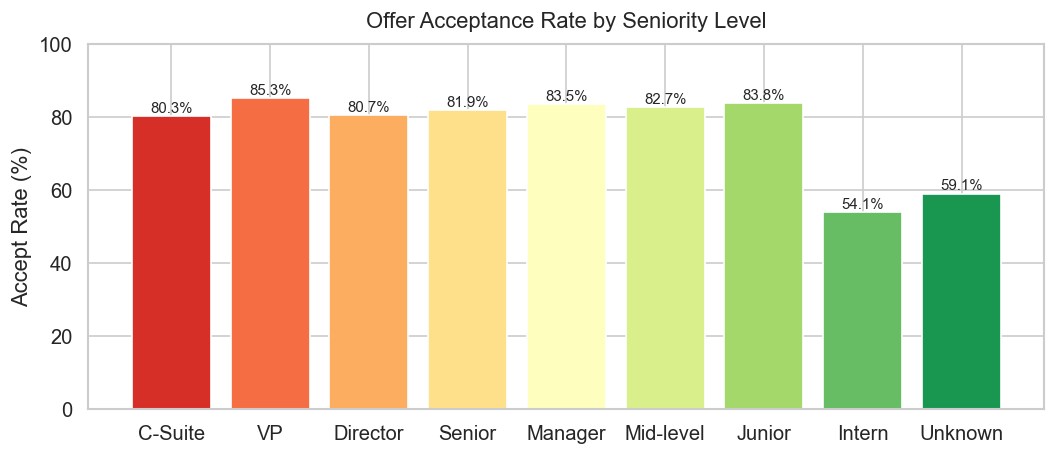

offer_outcome,accepted,lost,accept_rate
seniority_level,,,
C-Suite,561,138,80.3
VP,273,47,85.3
Director,2323,557,80.7
Senior,6211,1374,81.9
Manager,5672,1123,83.5
Mid-level,13445,2812,82.7
Junior,528,102,83.8
Intern,20,17,54.1
Unknown,343,237,59.1


In [351]:
# ── Taxa de aceitação por senioridade ─────────────────────────────────────
sen_outcome = (
    df[df['offer_outcome'].isin(['accepted', 'lost'])]
    .groupby(['seniority_level', 'offer_outcome'])
    .size()
    .unstack(fill_value=0)
)

sen_outcome['accept_rate'] = (
    sen_outcome.get('accepted', 0) /
    sen_outcome.sum(axis=1) * 100
).round(1)
sen_outcome = sen_outcome.reindex(seniority_order).dropna(how='all')

fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(sen_outcome.index, sen_outcome['accept_rate'],
       color=sns.color_palette('RdYlGn', len(sen_outcome)))
ax.set_title('Offer Acceptance Rate by Seniority Level')
ax.set_ylabel('Accept Rate (%)')
ax.set_ylim(0, 100)
for i, (idx, row) in enumerate(sen_outcome.iterrows()):
    ax.text(i, row['accept_rate'] + 1, f"{row['accept_rate']:.1f}%",
            ha='center', fontsize=9)
plt.tight_layout()
plt.show()

sen_outcome

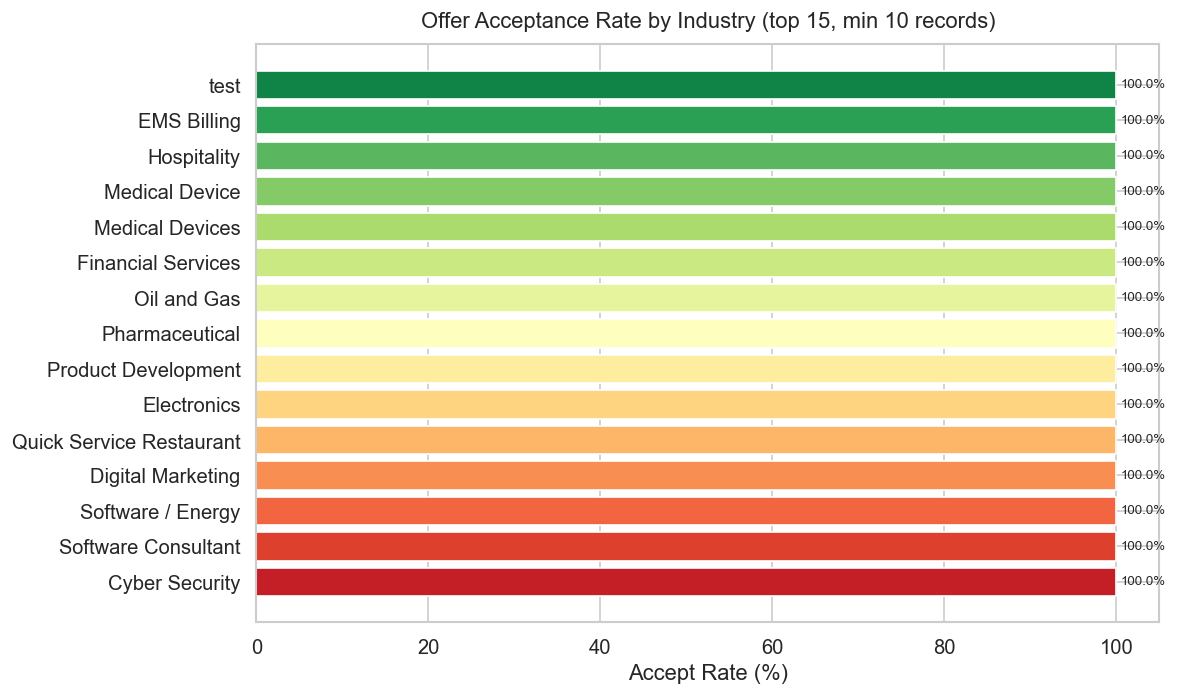

In [352]:
# ── Taxa de aceitação por indústria (top 15 indústrias com dados suficientes) ───
ind_outcome = (
    df[df['offer_outcome'].isin(['accepted', 'lost']) & df['offer_jobIndustry'].notna()]
    .groupby(['offer_jobIndustry', 'offer_outcome'])
    .size()
    .unstack(fill_value=0)
)
ind_outcome['total'] = ind_outcome.sum(axis=1)
ind_outcome['accept_rate'] = (
    ind_outcome.get('accepted', 0) / ind_outcome['total'] * 100
).round(1)

# mantém indústrias com pelo menos 10 registros
ind_top = (
    ind_outcome[ind_outcome['total'] >= 10]
    .sort_values('accept_rate', ascending=True)
    .tail(15)
)

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(ind_top.index, ind_top['accept_rate'],
               color=sns.color_palette('RdYlGn', len(ind_top)))
ax.set_title('Offer Acceptance Rate by Industry (top 15, min 10 records)')
ax.set_xlabel('Accept Rate (%)')
ax.set_xlim(0, 105)
for bar, val in zip(bars, ind_top['accept_rate']):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}%', va='center', fontsize=8)
plt.tight_layout()
plt.show()

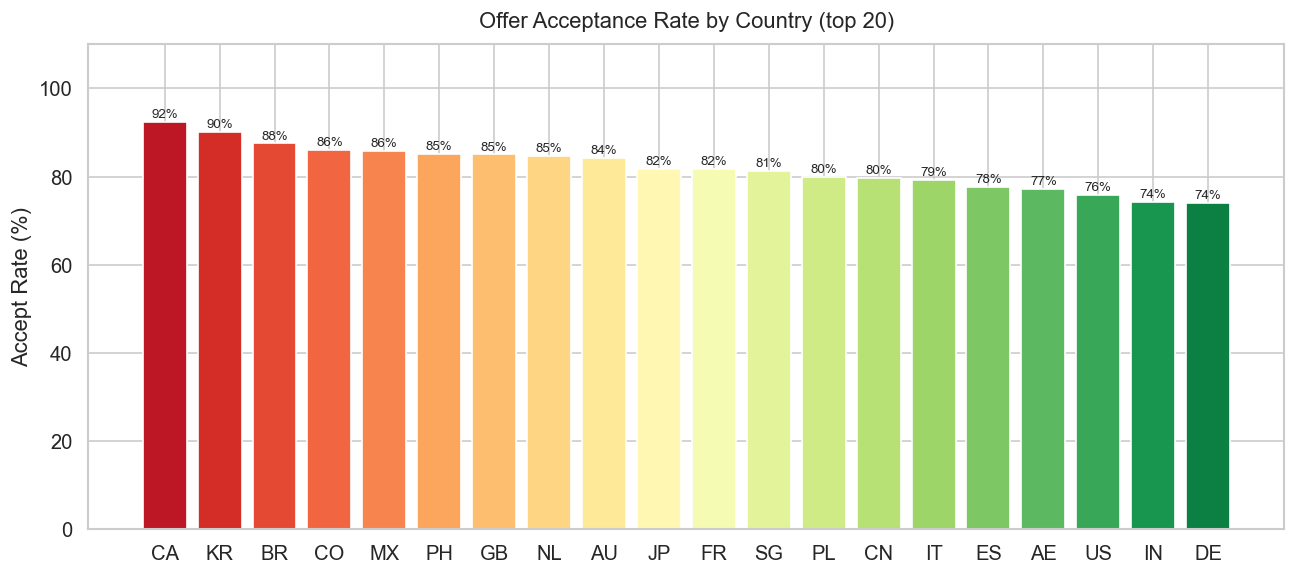

offer_outcome,accepted,lost,total,accept_rate
country,,,,
CA,4563,380,4943,92.3
KR,435,48,483,90.1
BR,1082,154,1236,87.5
CO,410,67,477,86.0
MX,1131,187,1318,85.8
PH,496,87,583,85.1
GB,2414,425,2839,85.0
NL,800,144,944,84.7
AU,1353,252,1605,84.3


In [353]:
# ── Taxa de aceitação por país (top 20) ───────────────────────────────────
top_country_list = df['country'].value_counts().head(20).index

ctry_outcome = (
    df[df['country'].isin(top_country_list) & df['offer_outcome'].isin(['accepted','lost'])]
    .groupby(['country', 'offer_outcome'])
    .size()
    .unstack(fill_value=0)
)
ctry_outcome['total'] = ctry_outcome.sum(axis=1)
ctry_outcome['accept_rate'] = (
    ctry_outcome.get('accepted', 0) / ctry_outcome['total'] * 100
).round(1)
ctry_outcome = ctry_outcome.sort_values('accept_rate', ascending=False)

fig, ax = plt.subplots(figsize=(11, 5))
colors = sns.color_palette('RdYlGn', len(ctry_outcome))
ax.bar(ctry_outcome.index, ctry_outcome['accept_rate'], color=colors)
ax.set_title('Offer Acceptance Rate by Country (top 20)')
ax.set_ylabel('Accept Rate (%)')
ax.set_ylim(0, 110)
for i, (idx, row) in enumerate(ctry_outcome.iterrows()):
    ax.text(i, row['accept_rate'] + 1, f"{row['accept_rate']:.0f}%",
            ha='center', fontsize=8)
plt.tight_layout()
plt.show()

ctry_outcome[['accepted', 'lost', 'total', 'accept_rate']]

---
## 7. Engenharia de Features

Novas colunas derivadas adicionadas ao `df`.

| Coluna | Origem | Lógica |
|---|---|---|
| `seniority_level` | `jobTitle` | correspondência de palavras-chave via regex (já criada na §3) |
| `offer_outcome` | `status` | accepted / lost / other (§6) |
| `job_function` | `jobTitle` | grupo funcional amplo (Engenharia, Vendas, RH, …) |
| `employment_type_norm` | `employmentType` | normalizado & simplificado |
| `pay_basis` | `annualGrossSalary`, `hourlyRate` | salário / por hora / desconhecido |
| `contract_type_norm` | `period` | indeterminado / determinado / desconhecido |
| `work_location_norm` | `offer_primaryWorkLocation` | remoto / híbrido / presencial / desconhecido |
| `is_visa_required` | `offer_isVisaWorkPermitRequired` | booleano |
| `start_year` | `startAt` | ano extraído |

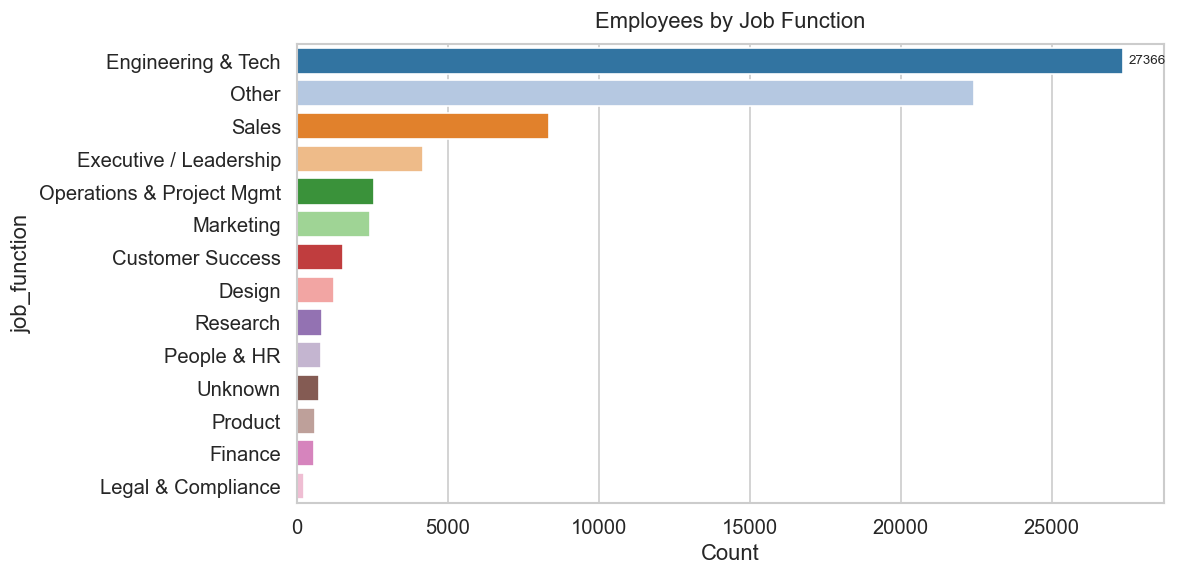

In [354]:
# ── job_function — grupo funcional amplo a partir do cargo ─────────────────
JOB_FUNCTION_MAP = [
    (r'engineer|developer|programmer|devops|architect|sre|data scientist|ml |machine learning|analyst|bi |data eng|full.?stack|front.?end|back.?end|cloud|infrastructure|platform|security|qa|test|quality', 'Engineering & Tech'),
    (r'sales|account executive|business development|bdr|sdr|revenue|partnerships', 'Sales'),
    (r'product manager|product owner|pm\b',   'Product'),
    (r'marketing|demand gen|growth|seo|content|brand|digital|communications', 'Marketing'),
    (r'finance|accountant|controller|treasury|payroll|tax|audit|fp&a|financial', 'Finance'),
    (r'hr |human resource|talent|recruiter|recruiting|people|hrbp|compensation|benefits|payroll', 'People & HR'),
    (r'legal|counsel|compliance|privacy|contract', 'Legal & Compliance'),
    (r'customer success|customer support|customer service|support engineer|implementation|onboarding|client service', 'Customer Success'),
    (r'operations|ops|supply chain|logistics|procurement|sourcing|project manager|program manager|scrum|agile|pmo', 'Operations & Project Mgmt'),
    (r'design|ux|ui |user experience|graphic|creative|visual', 'Design'),
    (r'executive|chief|president|vp |vice president|managing director|general manager|founder|ceo|cto|coo|cfo', 'Executive / Leadership'),
    (r'research|scientist|phd|postdoc', 'Research'),
]

def classify_function(title):
    if pd.isna(title):
        return 'Unknown'
    t = str(title).lower()
    for pattern, label in JOB_FUNCTION_MAP:
        if re.search(pattern, t):
            return label
    return 'Other'

df['job_function'] = df['jobTitle'].apply(classify_function)

jf_counts = df['job_function'].value_counts()

fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(x=jf_counts.values, y=jf_counts.index, ax=ax,
            palette='tab20')
ax.set_title('Employees by Job Function')
ax.set_xlabel('Count')
ax.bar_label(ax.containers[0], padding=3, fontsize=8)
plt.tight_layout()
plt.show()

In [355]:
# ── employment_type_norm ────────────────────────────────────────────────────
ETYPE_MAP = {
    'full_time':  'Full-time',
    'part_time':  'Part-time',
    'contractor': 'Contractor',
    'freelance':  'Freelance',
    'intern':     'Intern',
}
df['employment_type_norm'] = (
    df['employmentType']
    .str.lower().str.strip()
    .map(ETYPE_MAP)
    .fillna('Unknown')
)

# ── pay_basis ────────────────────────────────────────────────────────────
def pay_basis(row):
    has_salary = pd.notna(row.get('annualGrossSalary')) and row.get('annualGrossSalary', 0) > 0
    has_hourly = pd.notna(row.get('hourlyRate')) and row.get('hourlyRate', 0) > 0
    if has_salary and has_hourly:
        return 'Both'
    elif has_salary:
        return 'Salary'
    elif has_hourly:
        return 'Hourly'
    else:
        return 'Unknown'

df['pay_basis'] = df.apply(pay_basis, axis=1)

# ── contract_type_norm ──────────────────────────────────────────────────
CONTRACT_MAP = {'indefinite': 'Indefinite', 'fixed': 'Fixed-term'}
df['contract_type_norm'] = (
    df['period']
    .str.lower().str.strip()
    .map(CONTRACT_MAP)
    .fillna('Unknown')
)

# ── work_location_norm ──────────────────────────────────────────────────
LOCATION_MAP = {
    'home':   'Remote',
    'remote': 'Remote',
    'office': 'On-site',
    'onsite': 'On-site',
    'hybrid': 'Hybrid',
    'both':   'Hybrid',
}
df['work_location_norm'] = (
    df['offer_primaryWorkLocation']
    .str.lower().str.strip()
    .map(LOCATION_MAP)
    .fillna('Unknown')
)

# ── is_visa_required ──────────────────────────────────────────────────────
df['is_visa_required'] = (
    df['offer_isVisaWorkPermitRequired']
    .astype(str).str.lower().str.strip()
    .map({'yes': True, 'true': True, '1': True,
          'no': False, 'false': False, '0': False})
)

# ── start_year ────────────────────────────────────────────────────────────
df['start_year'] = pd.to_datetime(df['startAt'], errors='coerce').dt.year

# ── resumo ────────────────────────────────────────────────────────────────
new_cols = ['seniority_level', 'job_function', 'offer_outcome',
            'employment_type_norm', 'pay_basis', 'contract_type_norm',
            'work_location_norm', 'is_visa_required', 'start_year']

print('=== New engineered columns ===')
for c in new_cols:
    vc = df[c].value_counts(dropna=False)
    print(f'\n{c}:')
    print(vc.to_string())

=== New engineered columns ===

seniority_level:
seniority_level
Mid-level    43329
Senior       11732
Manager      10867
Director      4437
C-Suite       1126
Junior        1006
Unknown        743
VP             507
Intern         105

job_function:
job_function
Engineering & Tech           27366
Other                        22420
Sales                         8344
Executive / Leadership        4179
Operations & Project Mgmt     2555
Marketing                     2415
Customer Success              1547
Design                        1244
Research                       828
People & HR                    817
Unknown                        743
Product                        590
Finance                        562
Legal & Compliance             242

offer_outcome:
offer_outcome
other       38069
accepted    29376
lost         6407

employment_type_norm:
employment_type_norm
Unknown      45822
Full-time    27454
Part-time      576

pay_basis:
pay_basis
Unknown    44101
Salary     29751

cont

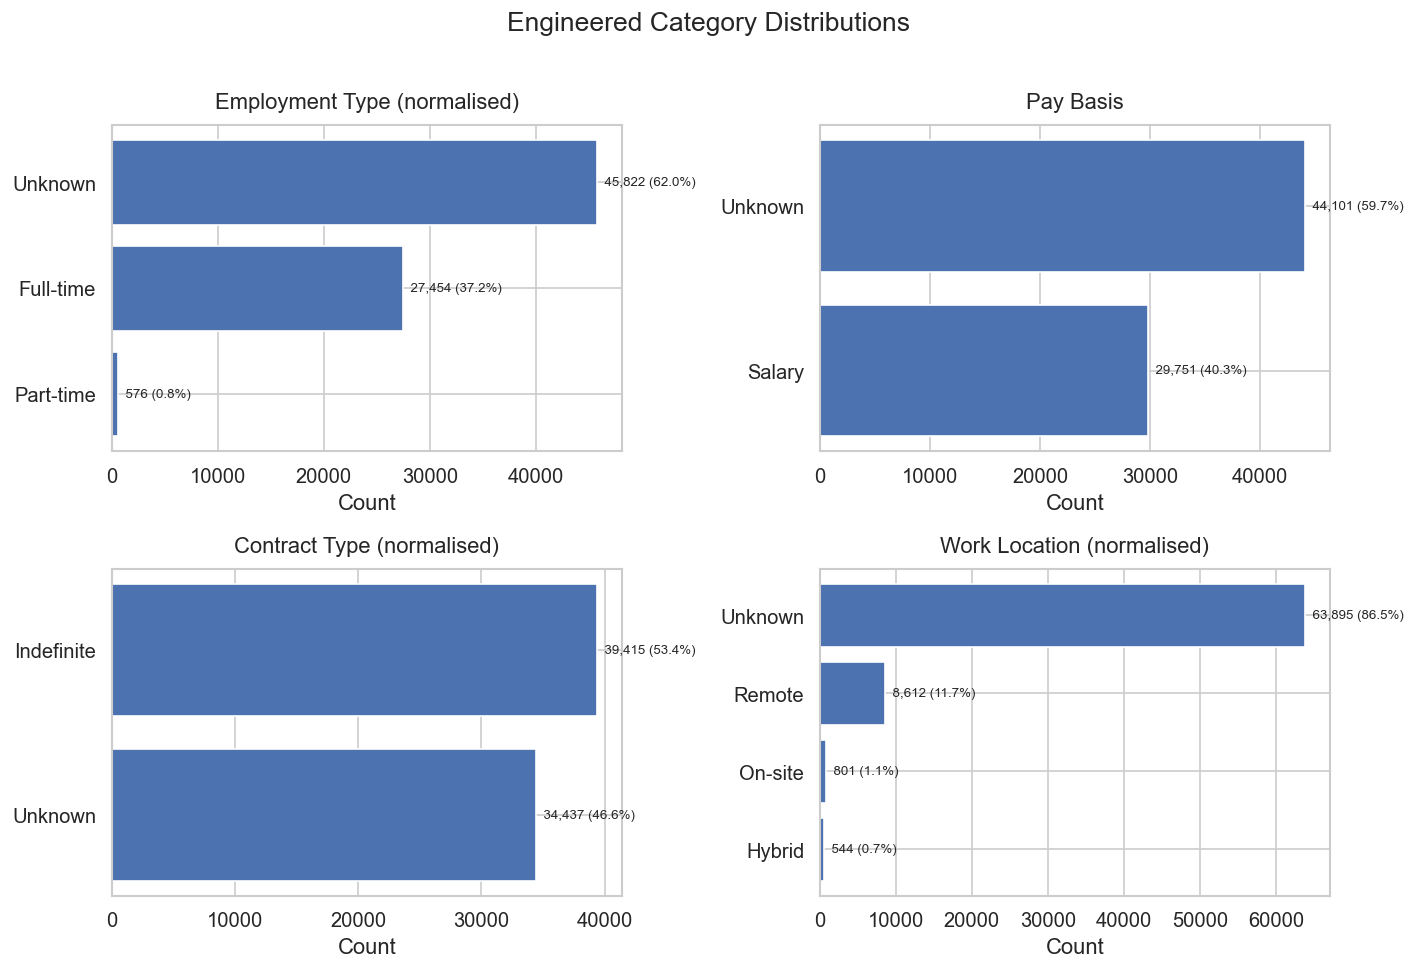

In [356]:
# ── Gráfico das categóricas derivadas ─────────────────────────────────────
cols_to_plot = [
    ('employment_type_norm', 'Employment Type (normalised)'),
    ('pay_basis',            'Pay Basis'),
    ('contract_type_norm',   'Contract Type (normalised)'),
    ('work_location_norm',   'Work Location (normalised)'),
]

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, (col, title) in zip(axes.flatten(), cols_to_plot):
    vc  = df[col].value_counts().sort_values()
    pct = vc / vc.sum() * 100
    bars = ax.barh(vc.index, vc.values, color=ACCENT)
    ax.set_title(title)
    ax.set_xlabel('Count')
    for bar, cnt, p in zip(bars, vc.values, pct.values):
        ax.text(bar.get_width(), bar.get_y() + bar.get_height() / 2,
                f'  {cnt:,} ({p:.1f}%)', va='center', fontsize=8)

plt.suptitle('Engineered Category Distributions', y=1.01)
plt.tight_layout()
plt.show()

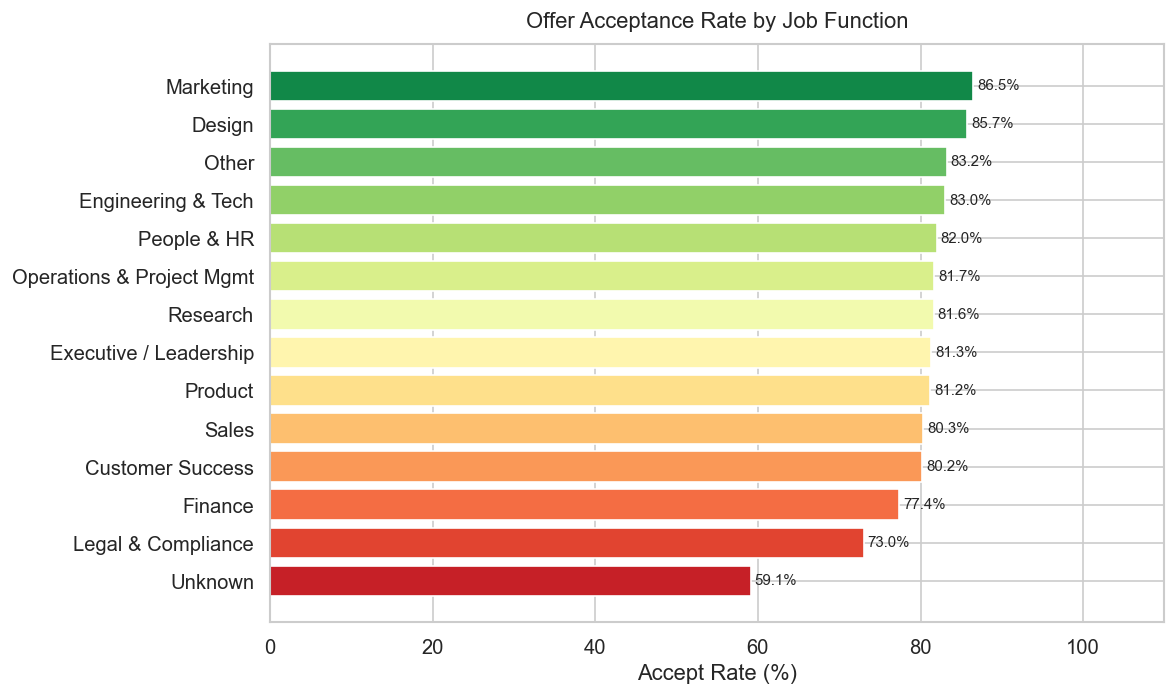

offer_outcome,accepted,lost,total,accept_rate
job_function,,,,
Unknown,343,237,580,59.1
Legal & Compliance,119,44,163,73.0
Finance,298,87,385,77.4
Customer Success,711,176,887,80.2
Sales,3761,924,4685,80.3
Product,272,63,335,81.2
Executive / Leadership,2129,489,2618,81.3
Research,417,94,511,81.6
Operations & Project Mgmt,1195,267,1462,81.7


In [357]:
# ── Resultado da proposta por função (apenas accepted vs. lost) ─────────────
fn_outcome = (
    df[df['offer_outcome'].isin(['accepted', 'lost'])]
    .groupby(['job_function', 'offer_outcome'])
    .size()
    .unstack(fill_value=0)
)
fn_outcome['total'] = fn_outcome.sum(axis=1)
fn_outcome['accept_rate'] = (
    fn_outcome.get('accepted', 0) / fn_outcome['total'] * 100
).round(1)
fn_outcome = fn_outcome.sort_values('accept_rate')

fig, ax = plt.subplots(figsize=(10, 6))
colors = sns.color_palette('RdYlGn', len(fn_outcome))
bars = ax.barh(fn_outcome.index, fn_outcome['accept_rate'], color=colors)
ax.set_title('Offer Acceptance Rate by Job Function')
ax.set_xlabel('Accept Rate (%)')
ax.set_xlim(0, 110)
for bar, val in zip(bars, fn_outcome['accept_rate']):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}%', va='center', fontsize=9)
plt.tight_layout()
plt.show()

fn_outcome[['accepted', 'lost', 'total', 'accept_rate']]

### 7b. Taxa de Vitória por Função

Mesma lógica de taxa de vitória das §6d–6f, aplicada aos grupos de `job_function` definidos
anteriormente nesta seção (colocado aqui, e não junto aos outros gráficos de WIN/LOSS, porque
`job_function` só é criada neste ponto do notebook).

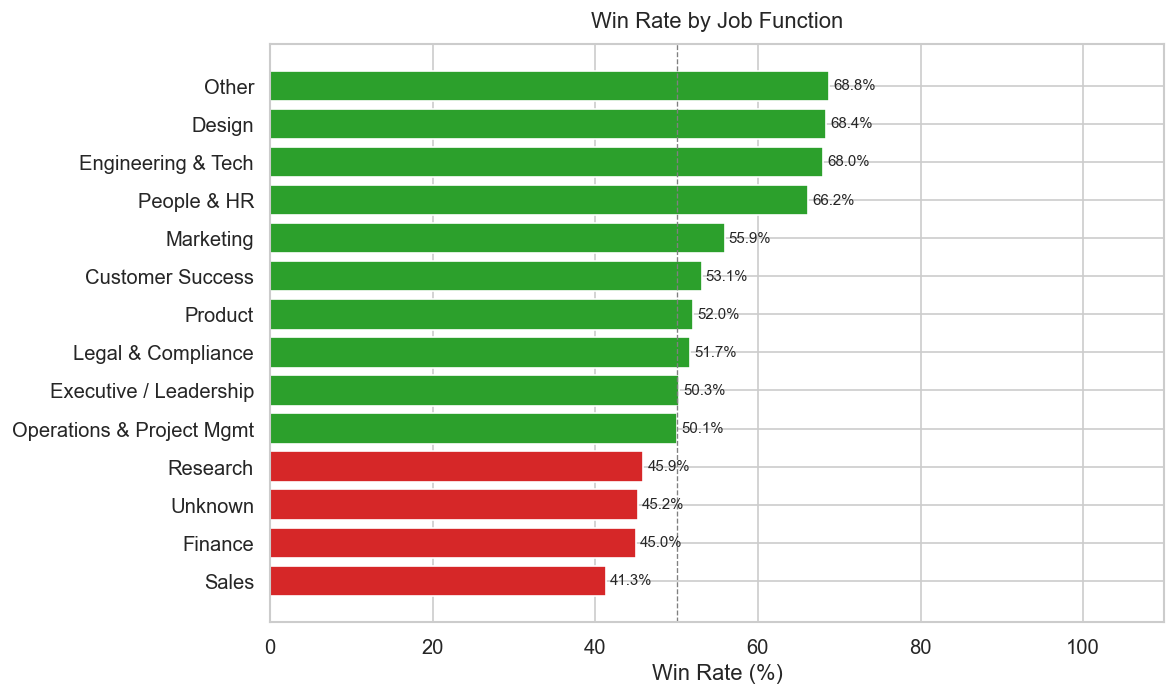

win_loss,WIN,LOSS,total,win_rate
job_function,,,,
Sales,3450,4894,8344,41.3
Finance,253,309,562,45.0
Unknown,336,407,743,45.2
Research,380,448,828,45.9
Operations & Project Mgmt,1280,1275,2555,50.1
Executive / Leadership,2104,2075,4179,50.3
Legal & Compliance,125,117,242,51.7
Product,307,283,590,52.0
Customer Success,822,725,1547,53.1


In [358]:
# ── Taxa de vitória por função ───────────────────────────────────────────────
fn_wl = (
    df[df['win_loss'].isin(['WIN', 'LOSS'])]
    .groupby(['job_function', 'win_loss'])
    .size()
    .unstack(fill_value=0)
)
fn_wl['total'] = fn_wl.sum(axis=1)
fn_wl['win_rate'] = (fn_wl.get('WIN', 0) / fn_wl['total'] * 100).round(1)
fn_wl = fn_wl.sort_values('win_rate')

fig, ax = plt.subplots(figsize=(10, 6))
colors = [wl_colors['WIN'] if v >= 50 else wl_colors['LOSS'] for v in fn_wl['win_rate']]
bars = ax.barh(fn_wl.index, fn_wl['win_rate'], color=colors)
ax.set_title('Win Rate by Job Function')
ax.set_xlabel('Win Rate (%)')
ax.set_xlim(0, 110)
ax.axvline(50, color='grey', ls='--', lw=0.8)
for bar, val in zip(bars, fn_wl['win_rate']):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height() / 2,
            f'{val:.1f}%', va='center', fontsize=9)
plt.tight_layout()
plt.show()

fn_wl[['WIN', 'LOSS', 'total', 'win_rate']]

---
## 8. Quais Atributos Mais Impactam o Resultado WIN / LOSS?

Para responder isso, medimos a força de associação entre cada atributo candidato e o resultado
`win_loss`:

- **Atributos categóricos** → V de Cramér, calculado a partir de uma tabela de contingência
  (0 = nenhuma associação, 1 = associação perfeita).
- **Atributos numéricos** → correlação ponto-bisserial com o resultado (WIN = 1 / LOSS = 0),
  em valor absoluto.

Ambas as métricas ficam numa escala aproximada de 0 a 1, o que permite comparar atributos de
tipos diferentes no mesmo ranking. Linhas com valor ausente no atributo são excluídas do
respectivo cálculo. `jobTitle` fica de fora por ter cardinalidade alta demais — seu sinal já é
capturado por `seniority_level` e `job_function`. `department` também fica de fora, por ser
majoritariamente dado de teste (§4).

In [359]:
# ── Métricas de associação: V de Cramér (categóricas) e correlação ponto-bisserial (numéricas) ──
from scipy.stats import chi2_contingency, pointbiserialr
from IPython.display import display

CATEGORICAL_CANDIDATES = [
    'seniority_level', 'job_function', 'employment_type_norm', 'pay_basis',
    'contract_type_norm', 'work_location_norm', 'is_visa_required',
    'country', 'offer_jobIndustry', 'solutionType', 'payFrequency',
    'offer_existingContractualRelationship',
]
NUMERIC_CANDIDATES = ['annualGrossSalary', 'start_year']

wl_df = df[df['win_loss'].isin(['WIN', 'LOSS'])].copy()

def cramers_v(col):
    tmp = wl_df[[col, 'win_loss']].dropna()
    if tmp[col].nunique() < 2:
        return np.nan, len(tmp)
    ct = pd.crosstab(tmp[col], tmp['win_loss'])
    chi2 = chi2_contingency(ct, correction=False)[0]
    n = ct.sum().sum()
    r, k = ct.shape
    return np.sqrt((chi2 / n) / (min(r, k) - 1)), n

def point_biserial(col):
    tmp = wl_df[[col, 'win_loss']].dropna()
    if tmp[col].nunique() < 2:
        return np.nan, len(tmp)
    target = (tmp['win_loss'] == 'WIN').astype(int)
    corr, _ = pointbiserialr(target, tmp[col])
    return abs(corr), len(tmp)

results = []
for col in CATEGORICAL_CANDIDATES:
    score, n = cramers_v(col)
    results.append({'attribute': col, 'type': 'categorical', 'association': score, 'n': n})
for col in NUMERIC_CANDIDATES:
    score, n = point_biserial(col)
    results.append({'attribute': col, 'type': 'numeric', 'association': score, 'n': n})

impact_df = (
    pd.DataFrame(results)
    .dropna(subset=['association'])
    .sort_values('association', ascending=False)
    .reset_index(drop=True)
)
impact_df

,attribute,type,association,n
0,offer_jobIndustry,categorical,0.583979,3733
1,start_year,numeric,0.428696,46124
2,payFrequency,categorical,0.421932,73852
3,country,categorical,0.350663,73852
4,pay_basis,categorical,0.333212,73852
5,seniority_level,categorical,0.270706,73852
6,job_function,categorical,0.207108,73852
7,contract_type_norm,categorical,0.166704,73852
8,work_location_norm,categorical,0.128403,73852
9,offer_existingContractualRelationship,categorical,0.114955,9729


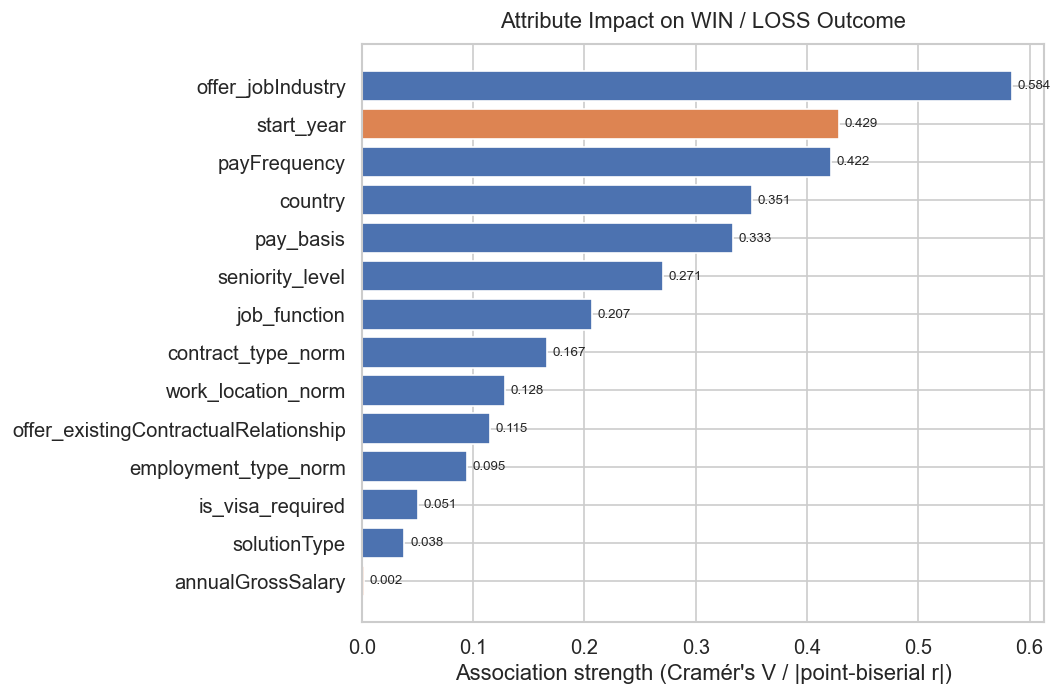

In [360]:
# ── Ranking visual da força de associação ──────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 6))
type_colors = {'categorical': ACCENT, 'numeric': '#dd8452'}
colors = [type_colors[t] for t in impact_df['type']][::-1]
bars = ax.barh(impact_df['attribute'][::-1], impact_df['association'][::-1], color=colors)
ax.set_xlabel("Association strength (Cramér's V / |point-biserial r|)")
ax.set_title('Attribute Impact on WIN / LOSS Outcome')
for bar, val in zip(bars, impact_df['association'][::-1]):
    ax.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height() / 2,
            f'{val:.3f}', va='center', fontsize=8)
plt.tight_layout()
plt.show()

### 8b. Análise Descritiva dos Atributos com Maior Impacto

Para cada um dos atributos no topo do ranking acima, geramos automaticamente:

- **Categóricos** → taxa de vitória (`win_rate`) por categoria (mínimo de 10 registros,
  mostrando as 15 categorias mais frequentes), no mesmo estilo verde/vermelho usado na §6.
- **Numéricos** → boxplot comparando a distribuição do atributo entre WIN e LOSS, mais a
  tabela `describe()` de cada grupo.


offer_jobIndustry  (association = 0.584, type = categorical)


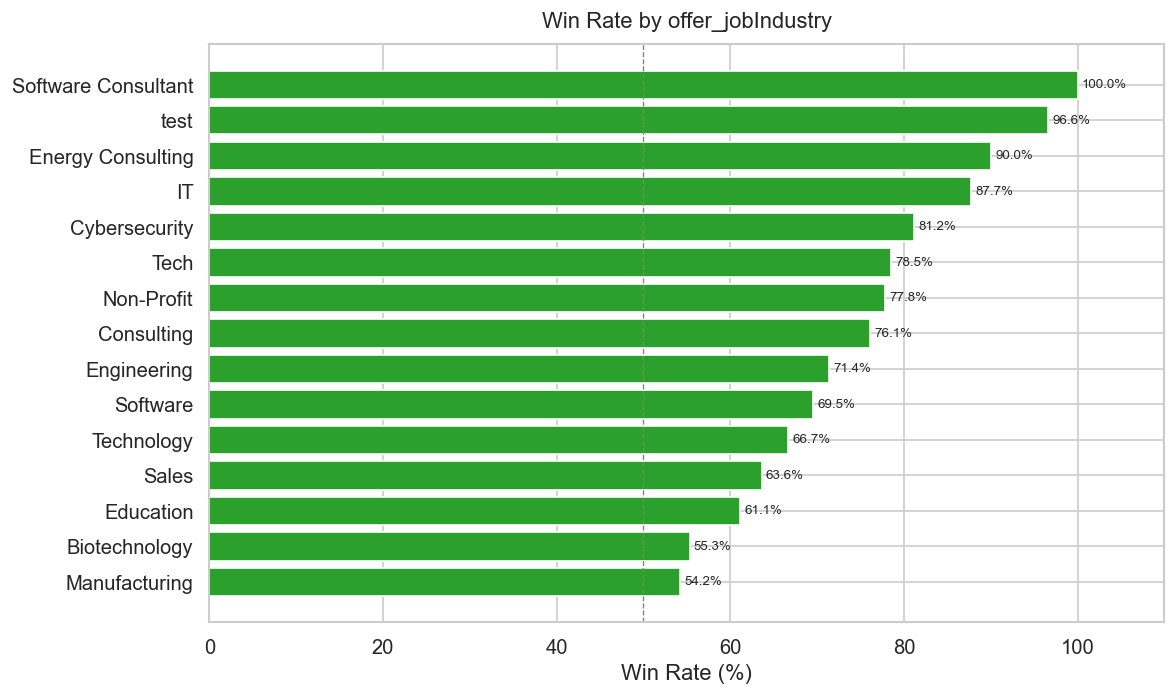

win_loss,WIN,LOSS,total,win_rate
offer_jobIndustry,,,,
Manufacturing,52,44,96,54.2
Biotechnology,21,17,38,55.3
Education,22,14,36,61.1
Sales,49,28,77,63.6
Technology,156,78,234,66.7
Software,91,40,131,69.5
Engineering,45,18,63,71.4
Consulting,35,11,46,76.1
Non-Profit,35,10,45,77.8



start_year  (association = 0.429, type = numeric)


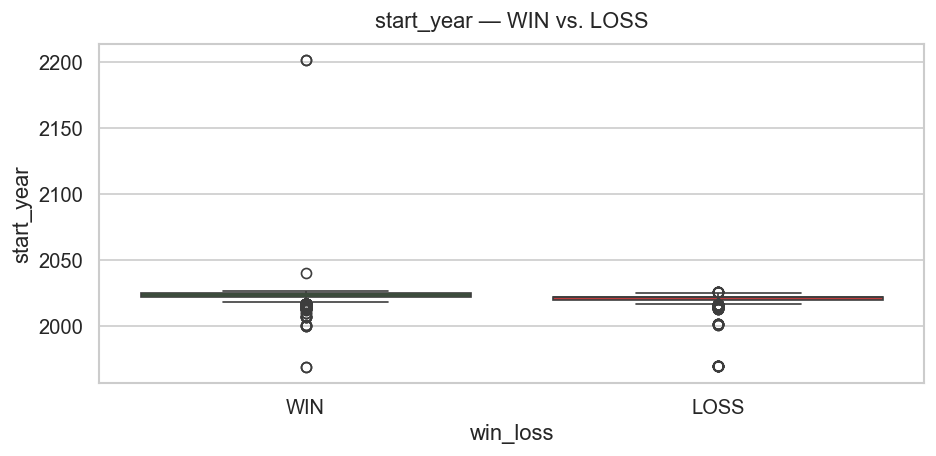

            count         mean       std     min     25%     50%     75%     max
win_loss                                                                        
LOSS      23261.0  2021.191780  1.996100  1970.0  2020.0  2022.0  2022.0  2026.0
WIN       22863.0  2023.444605  2.704481  1969.0  2022.0  2024.0  2025.0  2202.0

payFrequency  (association = 0.422, type = categorical)


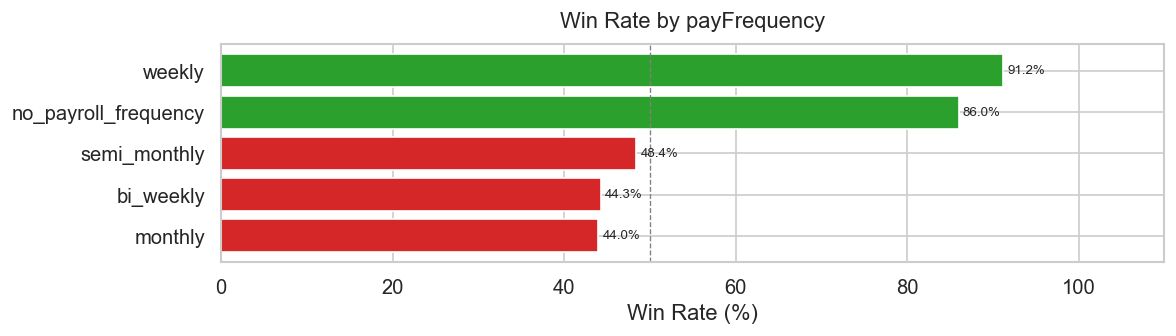

win_loss,WIN,LOSS,total,win_rate
payFrequency,,,,
monthly,15954,20315,36269,44.0
bi_weekly,116,146,262,44.3
semi_monthly,3020,3217,6237,48.4
no_payroll_frequency,26691,4336,31027,86.0
weekly,52,5,57,91.2



country  (association = 0.351, type = categorical)


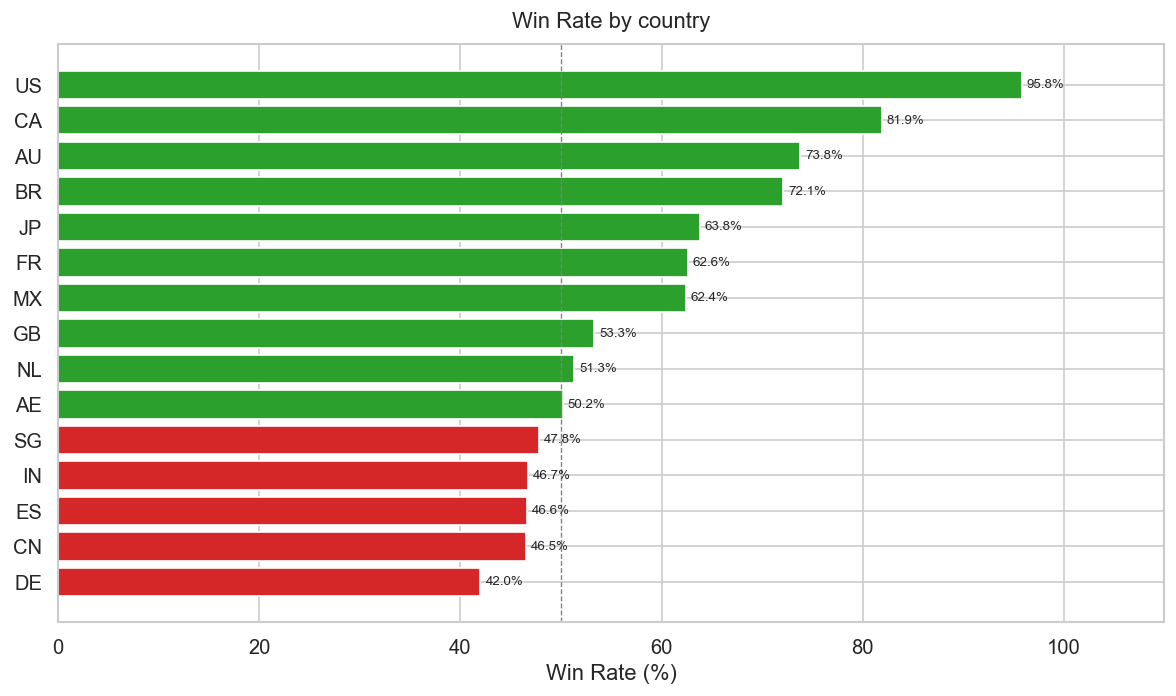

win_loss,WIN,LOSS,total,win_rate
country,,,,
DE,808,1114,1922,42.0
CN,705,810,1515,46.5
ES,1033,1182,2215,46.6
IN,2023,2309,4332,46.7
SG,810,883,1693,47.8
AE,642,636,1278,50.2
NL,846,802,1648,51.3
GB,2937,2576,5513,53.3
MX,1826,1100,2926,62.4



pay_basis  (association = 0.333, type = categorical)


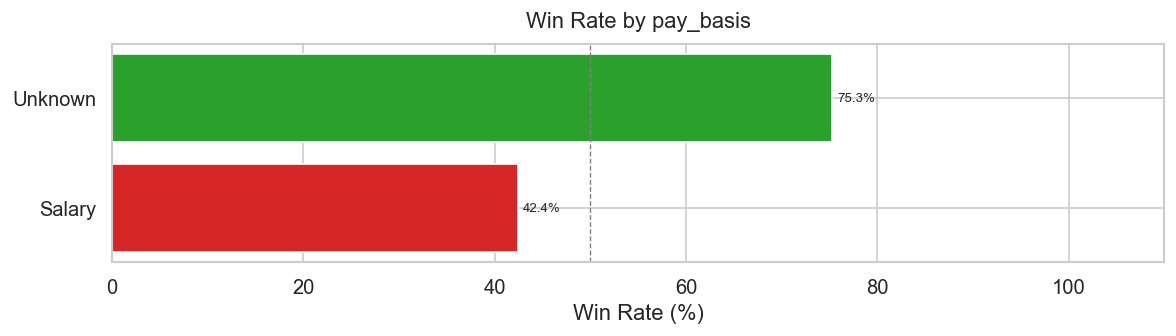

win_loss,WIN,LOSS,total,win_rate
pay_basis,,,,
Salary,12607,17144,29751,42.4
Unknown,33226,10875,44101,75.3


In [361]:
# ── Funções de análise descritiva reutilizáveis ────────────────────────────
def describe_categorical_attr(col, min_count=10, top_n=15):
    tmp = df[df['win_loss'].isin(['WIN', 'LOSS']) & df[col].notna()]
    grp = tmp.groupby([col, 'win_loss']).size().unstack(fill_value=0)
    grp['total'] = grp.sum(axis=1)
    grp['win_rate'] = (grp.get('WIN', 0) / grp['total'] * 100).round(1)
    grp = grp[grp['total'] >= min_count]
    grp = grp.sort_values('total', ascending=False).head(top_n)
    grp = grp.sort_values('win_rate')

    fig, ax = plt.subplots(figsize=(10, max(3, 0.4 * len(grp))))
    colors = [wl_colors['WIN'] if v >= 50 else wl_colors['LOSS'] for v in grp['win_rate']]
    bars = ax.barh(grp.index.astype(str), grp['win_rate'], color=colors)
    ax.set_title(f'Win Rate by {col}')
    ax.set_xlabel('Win Rate (%)')
    ax.set_xlim(0, 110)
    ax.axvline(50, color='grey', ls='--', lw=0.8)
    for bar, val in zip(bars, grp['win_rate']):
        ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height() / 2,
                f'{val:.1f}%', va='center', fontsize=8)
    plt.tight_layout()
    plt.show()
    return grp[['WIN', 'LOSS', 'total', 'win_rate']]

def describe_numeric_attr(col):
    tmp = df[df['win_loss'].isin(['WIN', 'LOSS']) & df[col].notna()]
    fig, ax = plt.subplots(figsize=(8, 4))
    sns.boxplot(data=tmp, x='win_loss', y=col, order=['WIN', 'LOSS'],
                palette={'WIN': wl_colors['WIN'], 'LOSS': wl_colors['LOSS']}, ax=ax)
    ax.set_title(f'{col} — WIN vs. LOSS')
    plt.tight_layout()
    plt.show()
    print(tmp.groupby('win_loss')[col].describe().to_string())

# ── Roda a análise descritiva para os atributos no topo do ranking ────────
TOP_N_ATTRS = 5
top_attrs = impact_df.head(TOP_N_ATTRS)

for _, row in top_attrs.iterrows():
    col = row['attribute']
    print(f"\n{'=' * 70}\n{col}  (association = {row['association']:.3f}, type = {row['type']})\n{'=' * 70}")
    if row['type'] == 'categorical':
        display(describe_categorical_attr(col))
    else:
        describe_numeric_attr(col)

### 8c. Ranking Refinado — Removendo Atributos Não Confiáveis

Dois atributos do ranking acima merecem ser removidos antes de tirar conclusões:

- **`start_year`** — é um artefato temporal (o ano em que o contrato começou), não um atributo
  que influencia a decisão de aceitar ou não a proposta; sua associação provavelmente reflete
  mudanças de processo/mercado ao longo do tempo, não uma causa acionável.
- **`offer_jobIndustry`** — está 94,8% vazio (apenas 1.835 de 35.366 linhas preenchidas), o
  mesmo problema de esparsidade/dado de teste já identificado para `department` na §4. Com uma
  amostra tão pequena, sua associação (a mais alta do ranking anterior) não é confiável.

Refazemos o ranking abaixo sem esses dois atributos.

In [362]:
# ── Ranking sem start_year e offer_jobIndustry ─────────────────────────────
EXCLUDED_ATTRS = ['start_year', 'offer_jobIndustry']

impact_df_clean = impact_df[~impact_df['attribute'].isin(EXCLUDED_ATTRS)].reset_index(drop=True)
impact_df_clean

,attribute,type,association,n
0,payFrequency,categorical,0.421932,73852
1,country,categorical,0.350663,73852
2,pay_basis,categorical,0.333212,73852
3,seniority_level,categorical,0.270706,73852
4,job_function,categorical,0.207108,73852
5,contract_type_norm,categorical,0.166704,73852
6,work_location_norm,categorical,0.128403,73852
7,offer_existingContractualRelationship,categorical,0.114955,9729
8,employment_type_norm,categorical,0.094828,73852
9,is_visa_required,categorical,0.050577,24239


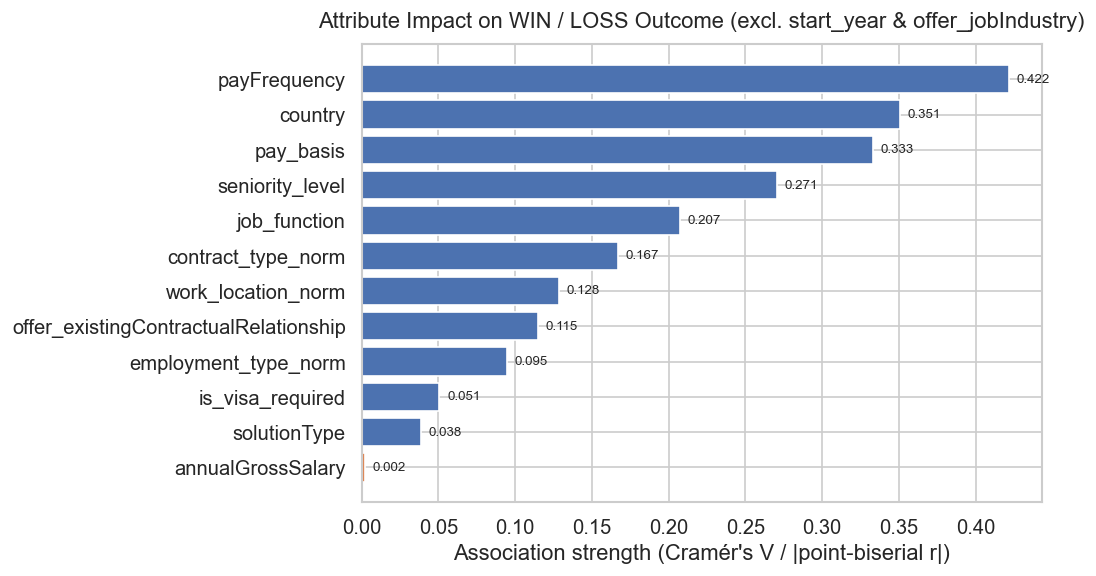

In [363]:
# ── Ranking visual refinado ──────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 5))
colors = [type_colors[t] for t in impact_df_clean['type']][::-1]
bars = ax.barh(impact_df_clean['attribute'][::-1], impact_df_clean['association'][::-1], color=colors)
ax.set_xlabel("Association strength (Cramér's V / |point-biserial r|)")
ax.set_title('Attribute Impact on WIN / LOSS Outcome (excl. start_year & offer_jobIndustry)')
for bar, val in zip(bars, impact_df_clean['association'][::-1]):
    ax.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height() / 2,
            f'{val:.3f}', va='center', fontsize=8)
plt.tight_layout()
plt.show()

### 8d. Análise Descritiva — Ranking Refinado

Mesmas funções descritivas da §8b, reaplicadas ao topo do ranking limpo (sem `start_year` e
`offer_jobIndustry`).


payFrequency  (association = 0.422, type = categorical)


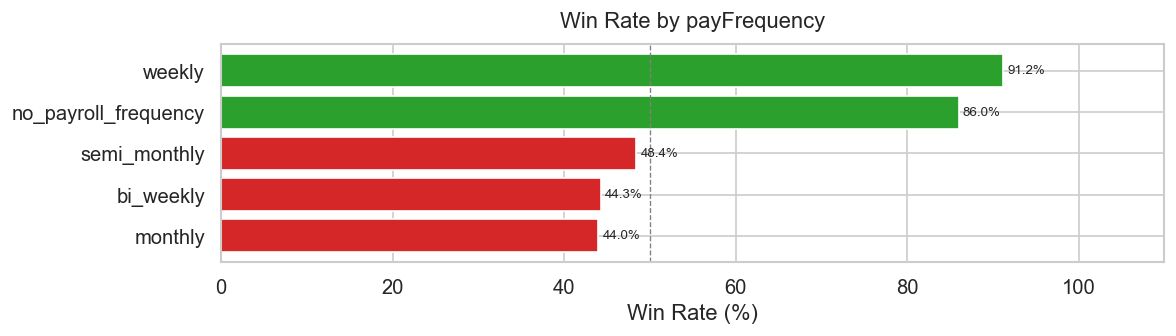

win_loss,WIN,LOSS,total,win_rate
payFrequency,,,,
monthly,15954,20315,36269,44.0
bi_weekly,116,146,262,44.3
semi_monthly,3020,3217,6237,48.4
no_payroll_frequency,26691,4336,31027,86.0
weekly,52,5,57,91.2



country  (association = 0.351, type = categorical)


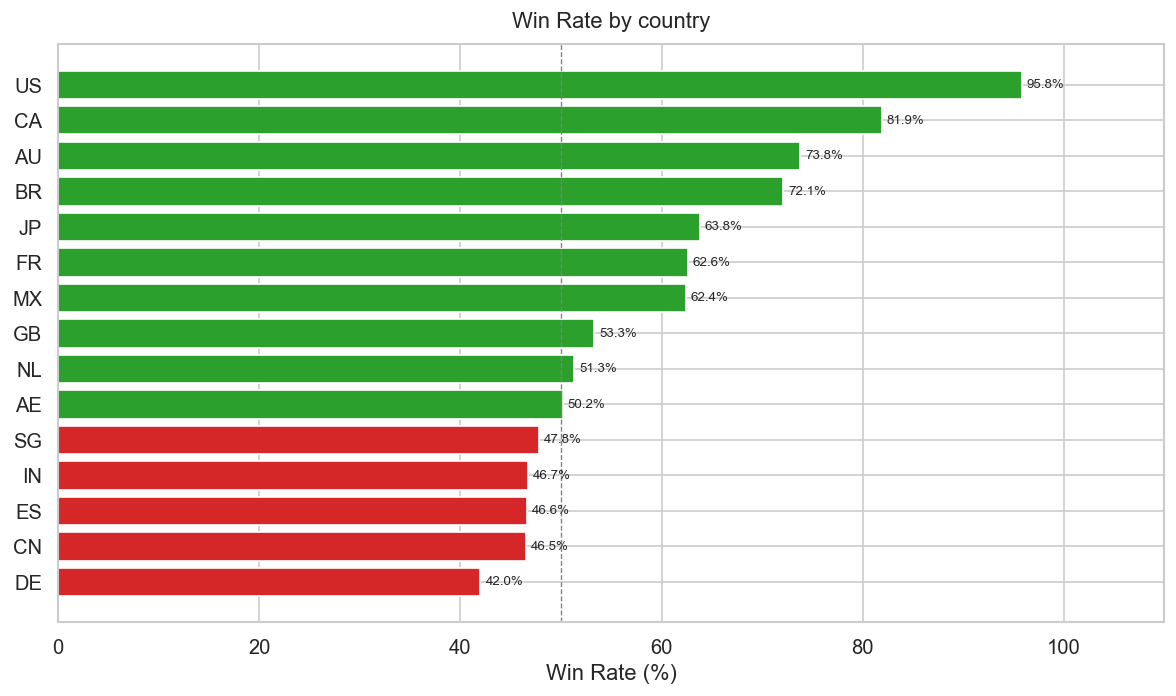

win_loss,WIN,LOSS,total,win_rate
country,,,,
DE,808,1114,1922,42.0
CN,705,810,1515,46.5
ES,1033,1182,2215,46.6
IN,2023,2309,4332,46.7
SG,810,883,1693,47.8
AE,642,636,1278,50.2
NL,846,802,1648,51.3
GB,2937,2576,5513,53.3
MX,1826,1100,2926,62.4



pay_basis  (association = 0.333, type = categorical)


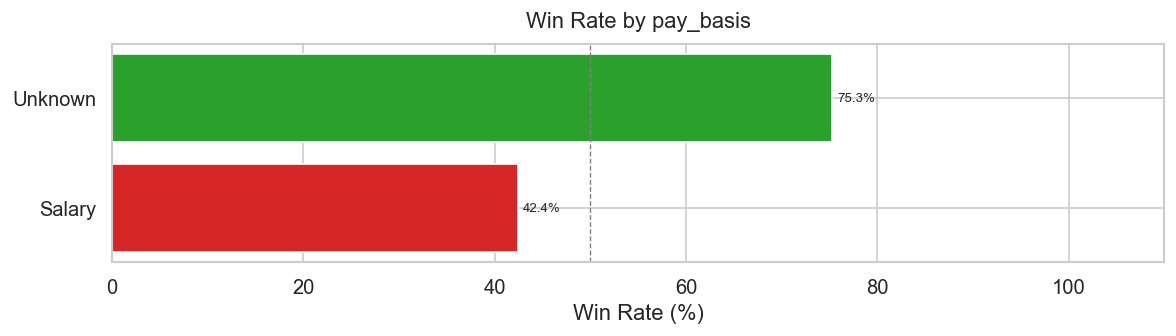

win_loss,WIN,LOSS,total,win_rate
pay_basis,,,,
Salary,12607,17144,29751,42.4
Unknown,33226,10875,44101,75.3



seniority_level  (association = 0.271, type = categorical)


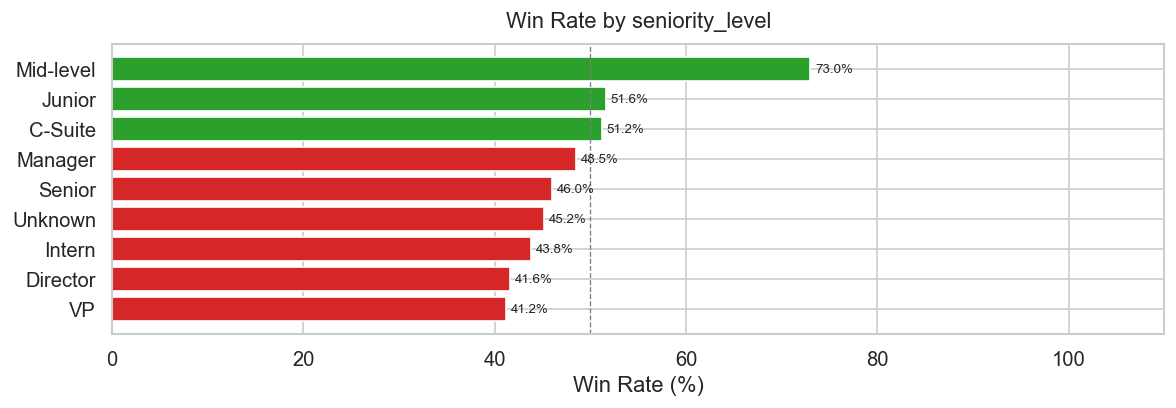

win_loss,WIN,LOSS,total,win_rate
seniority_level,,,,
VP,209,298,507,41.2
Director,1848,2589,4437,41.6
Intern,46,59,105,43.8
Unknown,336,407,743,45.2
Senior,5398,6334,11732,46.0
Manager,5275,5592,10867,48.5
C-Suite,576,550,1126,51.2
Junior,519,487,1006,51.6
Mid-level,31626,11703,43329,73.0



job_function  (association = 0.207, type = categorical)


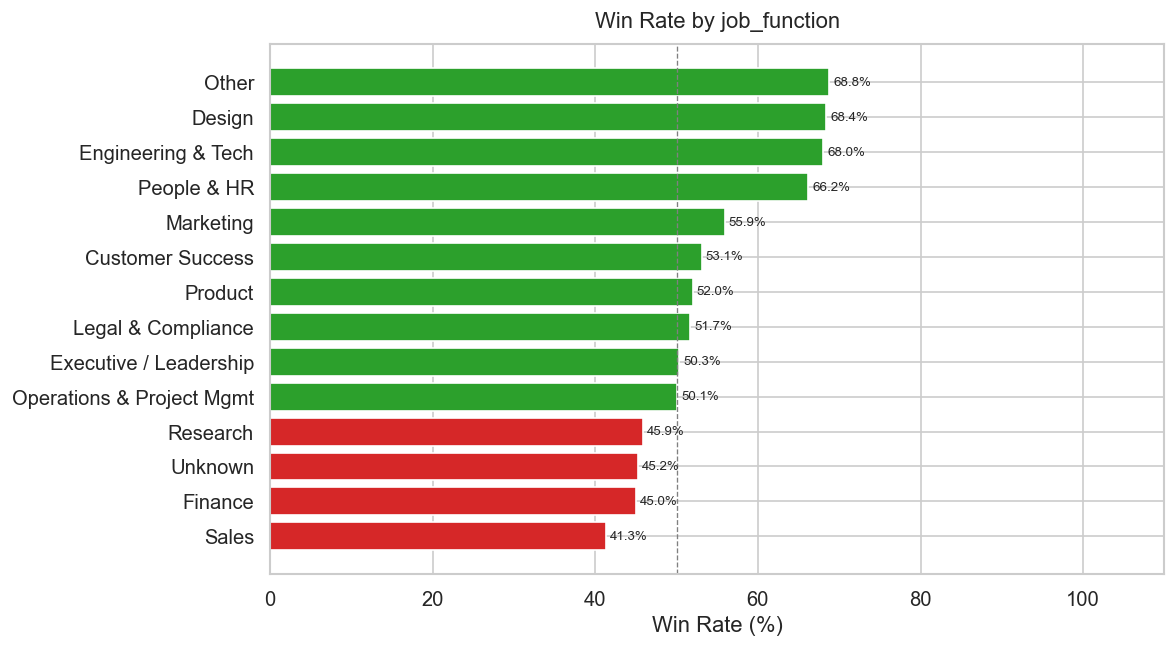

win_loss,WIN,LOSS,total,win_rate
job_function,,,,
Sales,3450,4894,8344,41.3
Finance,253,309,562,45.0
Unknown,336,407,743,45.2
Research,380,448,828,45.9
Operations & Project Mgmt,1280,1275,2555,50.1
Executive / Leadership,2104,2075,4179,50.3
Legal & Compliance,125,117,242,51.7
Product,307,283,590,52.0
Customer Success,822,725,1547,53.1


In [364]:
# ── Roda a análise descritiva para o topo do ranking refinado ─────────────
top_attrs_clean = impact_df_clean.head(TOP_N_ATTRS)

for _, row in top_attrs_clean.iterrows():
    col = row['attribute']
    print(f"\n{'=' * 70}\n{col}  (association = {row['association']:.3f}, type = {row['type']})\n{'=' * 70}")
    if row['type'] == 'categorical':
        display(describe_categorical_attr(col))
    else:
        describe_numeric_attr(col)

---
### 8e. Indo Além do Recorte Manual — Varredura de Todas as Colunas

As seções 8a–8d testaram apenas uma lista de ~14 atributos escolhidos manualmente. O dataset
bruto tem **125 colunas** — a maioria fica de fora por bons motivos (identificadores, textos
livres, timestamps, campos 100% vazios), mas excluir tudo isso "à mão" é arriscado: tanto por
esquecer um atributo relevante quanto por incluir por engano algo que não deveria estar ali.

Esta seção automatiza esse filtro com regras estruturais, e não com uma lista de bons palpites:

- **Identificadores** — nomes terminados em `Id`/`id` (ex.: `jobId`, `companyId`).
- **Datas/timestamps** — nomes terminados em `At`, `Date` ou `Deadline`.
- **Texto livre / identificador disfarçado** — colunas de texto (`object`) em que mais de 50%
  dos valores não nulos são únicos (ex.: `offer_companyName`, `offer_countrySpecificFields`).
- **Sem variação** — colunas com 0 ou 1 valor distinto (ex.: `hourlyRate`, 100% vazia nesta base).

Um pequeno número de colunas precisou de exclusão manual, porque nenhuma regra estrutural as
pega — só aparecem inspecionando os valores:

- `status`, `engagementStatus` — `win_loss` é derivado diretamente de `status`; comparar um
  atributo com sua própria origem é tautológico, não uma descoberta.
- `onboarding_status`, `onboarding_lostReason`, `onboarding_lostDate` — descrevem o mesmo
  processo de contratação sob outro rótulo (`lost`/`completed`/`duplicate`, e datas que só
  existem quando já houve perda); tratá-los como atributos "causadores" de WIN/LOSS seria
  vazamento de informação (data leakage), não uma associação real.
- `state` — o nome sugere geografia, mas ao inspecionar os valores (`df['state'].value_counts()`)
  descobrimos que a coluna guarda um **blob JSON com o próprio `ee_onboarding_status`** do
  processo — outro caso de vazamento disfarçado. A informação geográfica real está em
  `subdivision`.
- `jobTitle`, `jobDuties`, `legalFirstName`, `legalLastName` — texto livre / dados pessoais.
- `updatedBy`, `createdBy` — identificador interno de usuário/sistema, não um atributo do
  emprego.

As colunas já **engenheiradas** na §7 (`seniority_level`, `job_function`, `contract_type_norm`,
`work_location_norm`, `pay_basis`, `is_visa_required`) ficam de fora desta varredura porque são
versões tratadas de colunas brutas já cobertas aqui (`jobTitle`, `period`,
`offer_primaryWorkLocation`, `employmentType`) — seu sinal já apareceu nas §8a–8d.

In [365]:
# ── Classificação automática de todas as colunas brutas ────────────────────
ID_PATTERN = re.compile(r'(?i)(^id$|Id$)')
DATE_PATTERN = re.compile(r'(?i)(At$|Date$|Deadline$)')
EXPLICIT_EXCLUDE = {
    'status', 'engagementStatus',
    'onboarding_status', 'onboarding_lostReason', 'onboarding_lostDate',
    'state',  # não é geografia: blob JSON com ee_onboarding_status (vazamento) — ver §8e
    'jobTitle', 'jobDuties', 'legalFirstName', 'legalLastName',
    'updatedBy', 'createdBy',
}

excluded_cols = []
categorical_cols = []
numeric_cols = []

for col in df_raw.columns:
    if col in EXPLICIT_EXCLUDE:
        excluded_cols.append((col, 'excluído manualmente (vazamento/texto livre/id de sistema)'))
        continue
    if ID_PATTERN.search(col):
        excluded_cols.append((col, 'identificador (nome termina em Id)'))
        continue
    if DATE_PATTERN.search(col):
        excluded_cols.append((col, 'data/timestamp'))
        continue
    s = df_raw[col]
    non_null = s.notna().sum()
    nunique = s.nunique(dropna=True)
    if non_null == 0 or nunique <= 1:
        excluded_cols.append((col, 'sem variação'))
        continue
    if s.dtype == object and (nunique / non_null) > 0.5:
        excluded_cols.append((col, f'cardinalidade alta (texto livre/identificador) [{nunique}/{non_null}]'))
        continue
    if s.dtype in (np.float64, np.int64) and nunique > 20:
        numeric_cols.append(col)
    else:
        categorical_cols.append(col)

print(f'Colunas brutas totais       : {len(df_raw.columns)}')
print(f'Candidatas categóricas      : {len(categorical_cols)}')
print(f'Candidatas numéricas        : {len(numeric_cols)}')
print(f'Excluídas estruturalmente   : {len(excluded_cols)}')

Colunas brutas totais       : 125
Candidatas categóricas      : 50
Candidatas numéricas        : 18
Excluídas estruturalmente   : 57


In [366]:
# ── Tabela de colunas excluídas, com o motivo ──────────────────────────────
pd.DataFrame(excluded_cols, columns=['coluna', 'motivo']).sort_values('motivo')

,coluna,motivo
42,offer_companyName,cardinalidade alta (texto livre/identificador)...
52,offer_updatedByIp,cardinalidade alta (texto livre/identificador)...
16,department,cardinalidade alta (texto livre/identificador)...
18,expectedEndDate,data/timestamp
35,onboarding_eeInfoCompletedAt,data/timestamp
34,onboarding_eeInfoStartedAt,data/timestamp
33,onboarding_eeFirstLoggedInAt,data/timestamp
32,onboarding_finalizedDate,data/timestamp
46,offer_contractDraftingDeadline,data/timestamp
36,onboarding_offerFinalizedAt,data/timestamp


In [367]:
# ── Associação de TODAS as colunas candidatas com win_loss (reaproveita cramers_v / point_biserial da §8a) ──
full_results = []
for col in categorical_cols:
    score, n = cramers_v(col)
    full_results.append({'attribute': col, 'type': 'categorical', 'association': score, 'n': n})
for col in numeric_cols:
    score, n = point_biserial(col)
    full_results.append({'attribute': col, 'type': 'numeric', 'association': score, 'n': n})

full_impact_df = (
    pd.DataFrame(full_results)
    .dropna(subset=['association'])
    .sort_values('association', ascending=False)
    .reset_index(drop=True)
)
print(f'{len(full_impact_df)} colunas testadas com sucesso (de {len(categorical_cols) + len(numeric_cols)} candidatas)')
full_impact_df

67 colunas testadas com sucesso (de 68 candidatas)


,attribute,type,association,n
0,offer_schoolAllowanceAmount,categorical,1.000000,58
1,offer_countrySpecificFields,categorical,0.777403,17850
2,offer_monthlyAllowance1Description,categorical,0.680711,439
3,offer_jobIndustry,categorical,0.583979,3733
4,offer_flightAllowanceAmount,categorical,0.579987,68
...,...,...,...,...
62,offer_workingHoursPerWeek,numeric,0.005175,21163
63,offer_retirementMatchBasis,categorical,0.004604,491
64,offer_monthlyAllowance1Amount,numeric,0.002493,451
65,annualGrossSalary,numeric,0.001831,30850


### 8f. Filtrando por Tamanho de Amostra

Assim como `offer_jobIndustry` nas §8c/8d, muitas colunas acima têm um `n` minúsculo — a
maioria das colunas de benefícios (`offer_*Amount`, `offer_is*Offered`) está 95–100% vazia, e
uma associação "perfeita" calculada sobre 20 ou 30 registros não é confiável, é ruído
estatístico. Aplicamos um corte mínimo de amostra (`n ≥ 1.000`) antes de olhar para o topo do
ranking — a tabela completa acima continua disponível para quem quiser investigar os atributos
mais raros com essa ressalva em mente.

In [368]:
# ── Ranking confiável (amostra mínima de 1.000 registros) ──────────────────
MIN_N = 1000
reliable_impact_df = full_impact_df[full_impact_df['n'] >= MIN_N].reset_index(drop=True)
reliable_impact_df.head(20)

,attribute,type,association,n
0,offer_countrySpecificFields,categorical,0.777403,17850
1,offer_jobIndustry,categorical,0.583979,3733
2,payFrequency,categorical,0.421932,73852
3,country,categorical,0.350663,73852
4,payrollCurrencyCode,categorical,0.318771,71848
5,subdivision,categorical,0.235190,7036
6,offer_supplementalLifeInsuranceAmount,categorical,0.205540,4210
7,shareKeyTermsWithEmployee,categorical,0.176916,73852
8,offer_isOfferingSignOnBonus,categorical,0.151548,2352
9,offer_isOfferFinalized,categorical,0.141595,64786


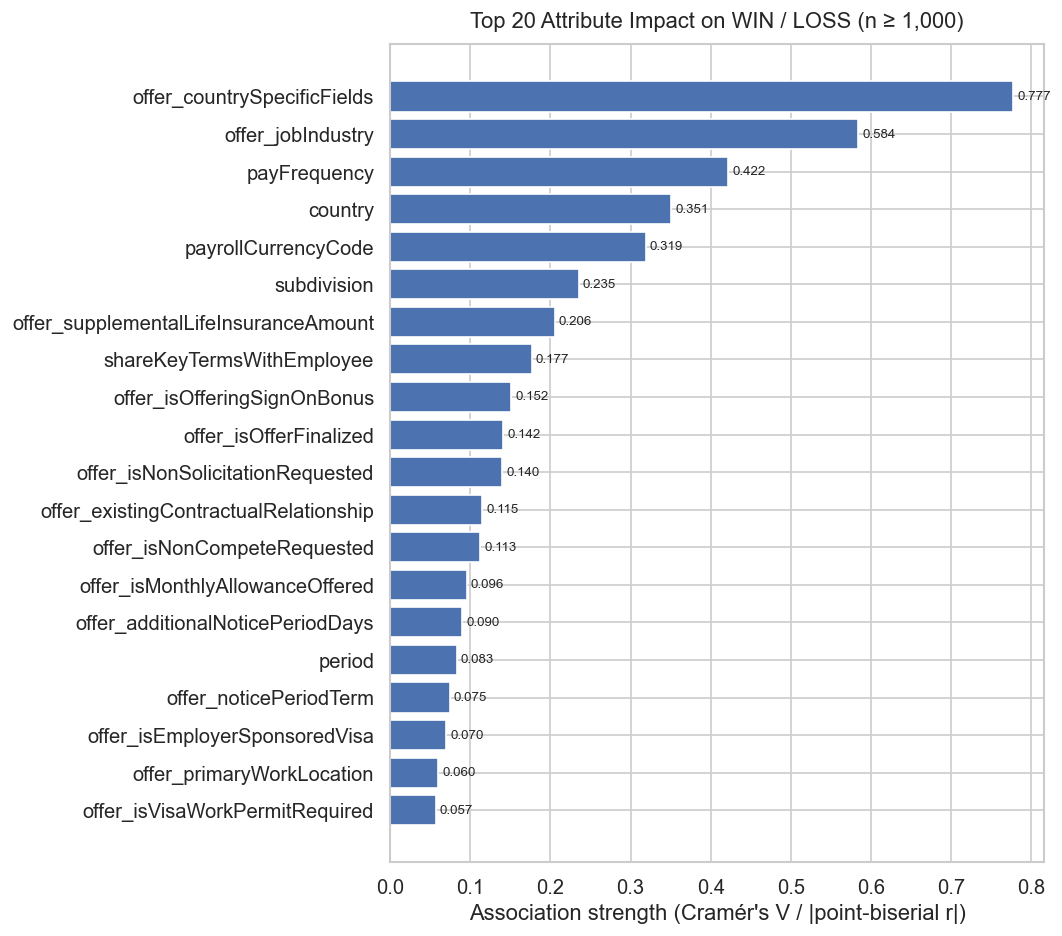

In [369]:
# ── Ranking visual — top 20 confiáveis ──────────────────────────────────────
top20 = reliable_impact_df.head(20)
fig, ax = plt.subplots(figsize=(9, 8))
colors = [type_colors[t] for t in top20['type']][::-1]
bars = ax.barh(top20['attribute'][::-1], top20['association'][::-1], color=colors)
ax.set_xlabel("Association strength (Cramér's V / |point-biserial r|)")
ax.set_title(f'Top 20 Attribute Impact on WIN / LOSS (n ≥ {MIN_N:,})')
for bar, val in zip(bars, top20['association'][::-1]):
    ax.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height() / 2,
            f'{val:.3f}', va='center', fontsize=8)
plt.tight_layout()
plt.show()

### 8g. Como Ler Este Ranking Ampliado

A varredura completa confirma os atributos já encontrados nas §8a–8d (`payFrequency`,
`country`, `pay_basis`/`period`, `offer_primaryWorkLocation`) e revela novos candidatos que não
estavam na lista curada original — mas alguns pedem cautela extra:

- **`subdivision`** (estado/província) e **`payrollCurrencyCode`** são geograficamente
  coerentes com `country` já estar no topo — vale investigar se estão captando o mesmo sinal
  (país) de outro ângulo, e não três descobertas independentes.
- **`offer_jobIndustry`** ainda aparece alto mesmo após o corte de amostra (`n = 1.835` passa de
  1.000), mas continua sendo apenas ~5% da base — o `n` absoluto ser aceitável não elimina o
  risco de viés de seleção (por que só esses 5% têm indústria preenchida?). Trate como hipótese
  a validar, não como conclusão.
- **Colunas monetárias** (`offer_supplementalLifeInsuranceAmount`, `offer_retirementMatchPercentage`
  e qualquer `offer_*Amount`) herdam o mesmo problema de mistura de moedas sem conversão
  cambial já visto para `annualGrossSalary` — ver a notebook `nb_analise_descritiva.ipynb`,
  §6a, para o detalhe.
- **`offer_isOfferFinalized`, `offer_isNonCompeteRequested`, `offer_isNonSolicitationRequested`**
  são termos contratuais genuínos, mas também podem refletir o quão longe o processo avançou —
  a mesma cautela de "sintoma vs. causa" aplicada a `onboarding_status` vale aqui, só que de
  forma mais sutil (por isso não foram excluídos, apenas sinalizados).

Em resumo: a varredura automática é mais completa e mais honesta do que uma lista de palpites,
mas não substitui o julgamento — ela só torna mais fácil ver **onde** aplicar esse julgamento.